In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

In [3]:
# plot sizing
options(repr.plot.width=20, repr.plot.height=15)

# looking in depth at p asteroides 
- transect
- changes in alpha diversity of PAST 

In [4]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

## cleaning ps object

### isolate samples that are PAST

In [5]:
ps_past <- subset_samples(ps, Species == "PAST") 
nrow(sample_data(ps_past))#96
ps_past

[1] 97

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 97 samples ]
sample_data() Sample Data:       [ 97 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

### remove PAST colonies that were ever diseased

In [6]:
# Remove samples where Treatment is "Blank" AND Environment is "Water"
ps_past_nodisease <- subset_samples(ps_past, colony != "1_19" & colony != "1_20" & colony != "2_56" & colony != "3_18")
ps_past_nodisease

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 81 samples ]
sample_data() Sample Data:       [ 81 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

### remove unimportant taxa and reads under 10K

In [7]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps_past_nodisease) >= 10000, ps_past_nodisease)
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 81 samples ]
sample_data() Sample Data:       [ 81 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [8]:
#removing any taxa that don't show up in any samples to speed up the process
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 25905 taxa and 81 samples ]
sample_data() Sample Data:       [ 81 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 25905 taxa by 6 taxonomic ranks ]

### alpha diversity plots for ps_prune

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


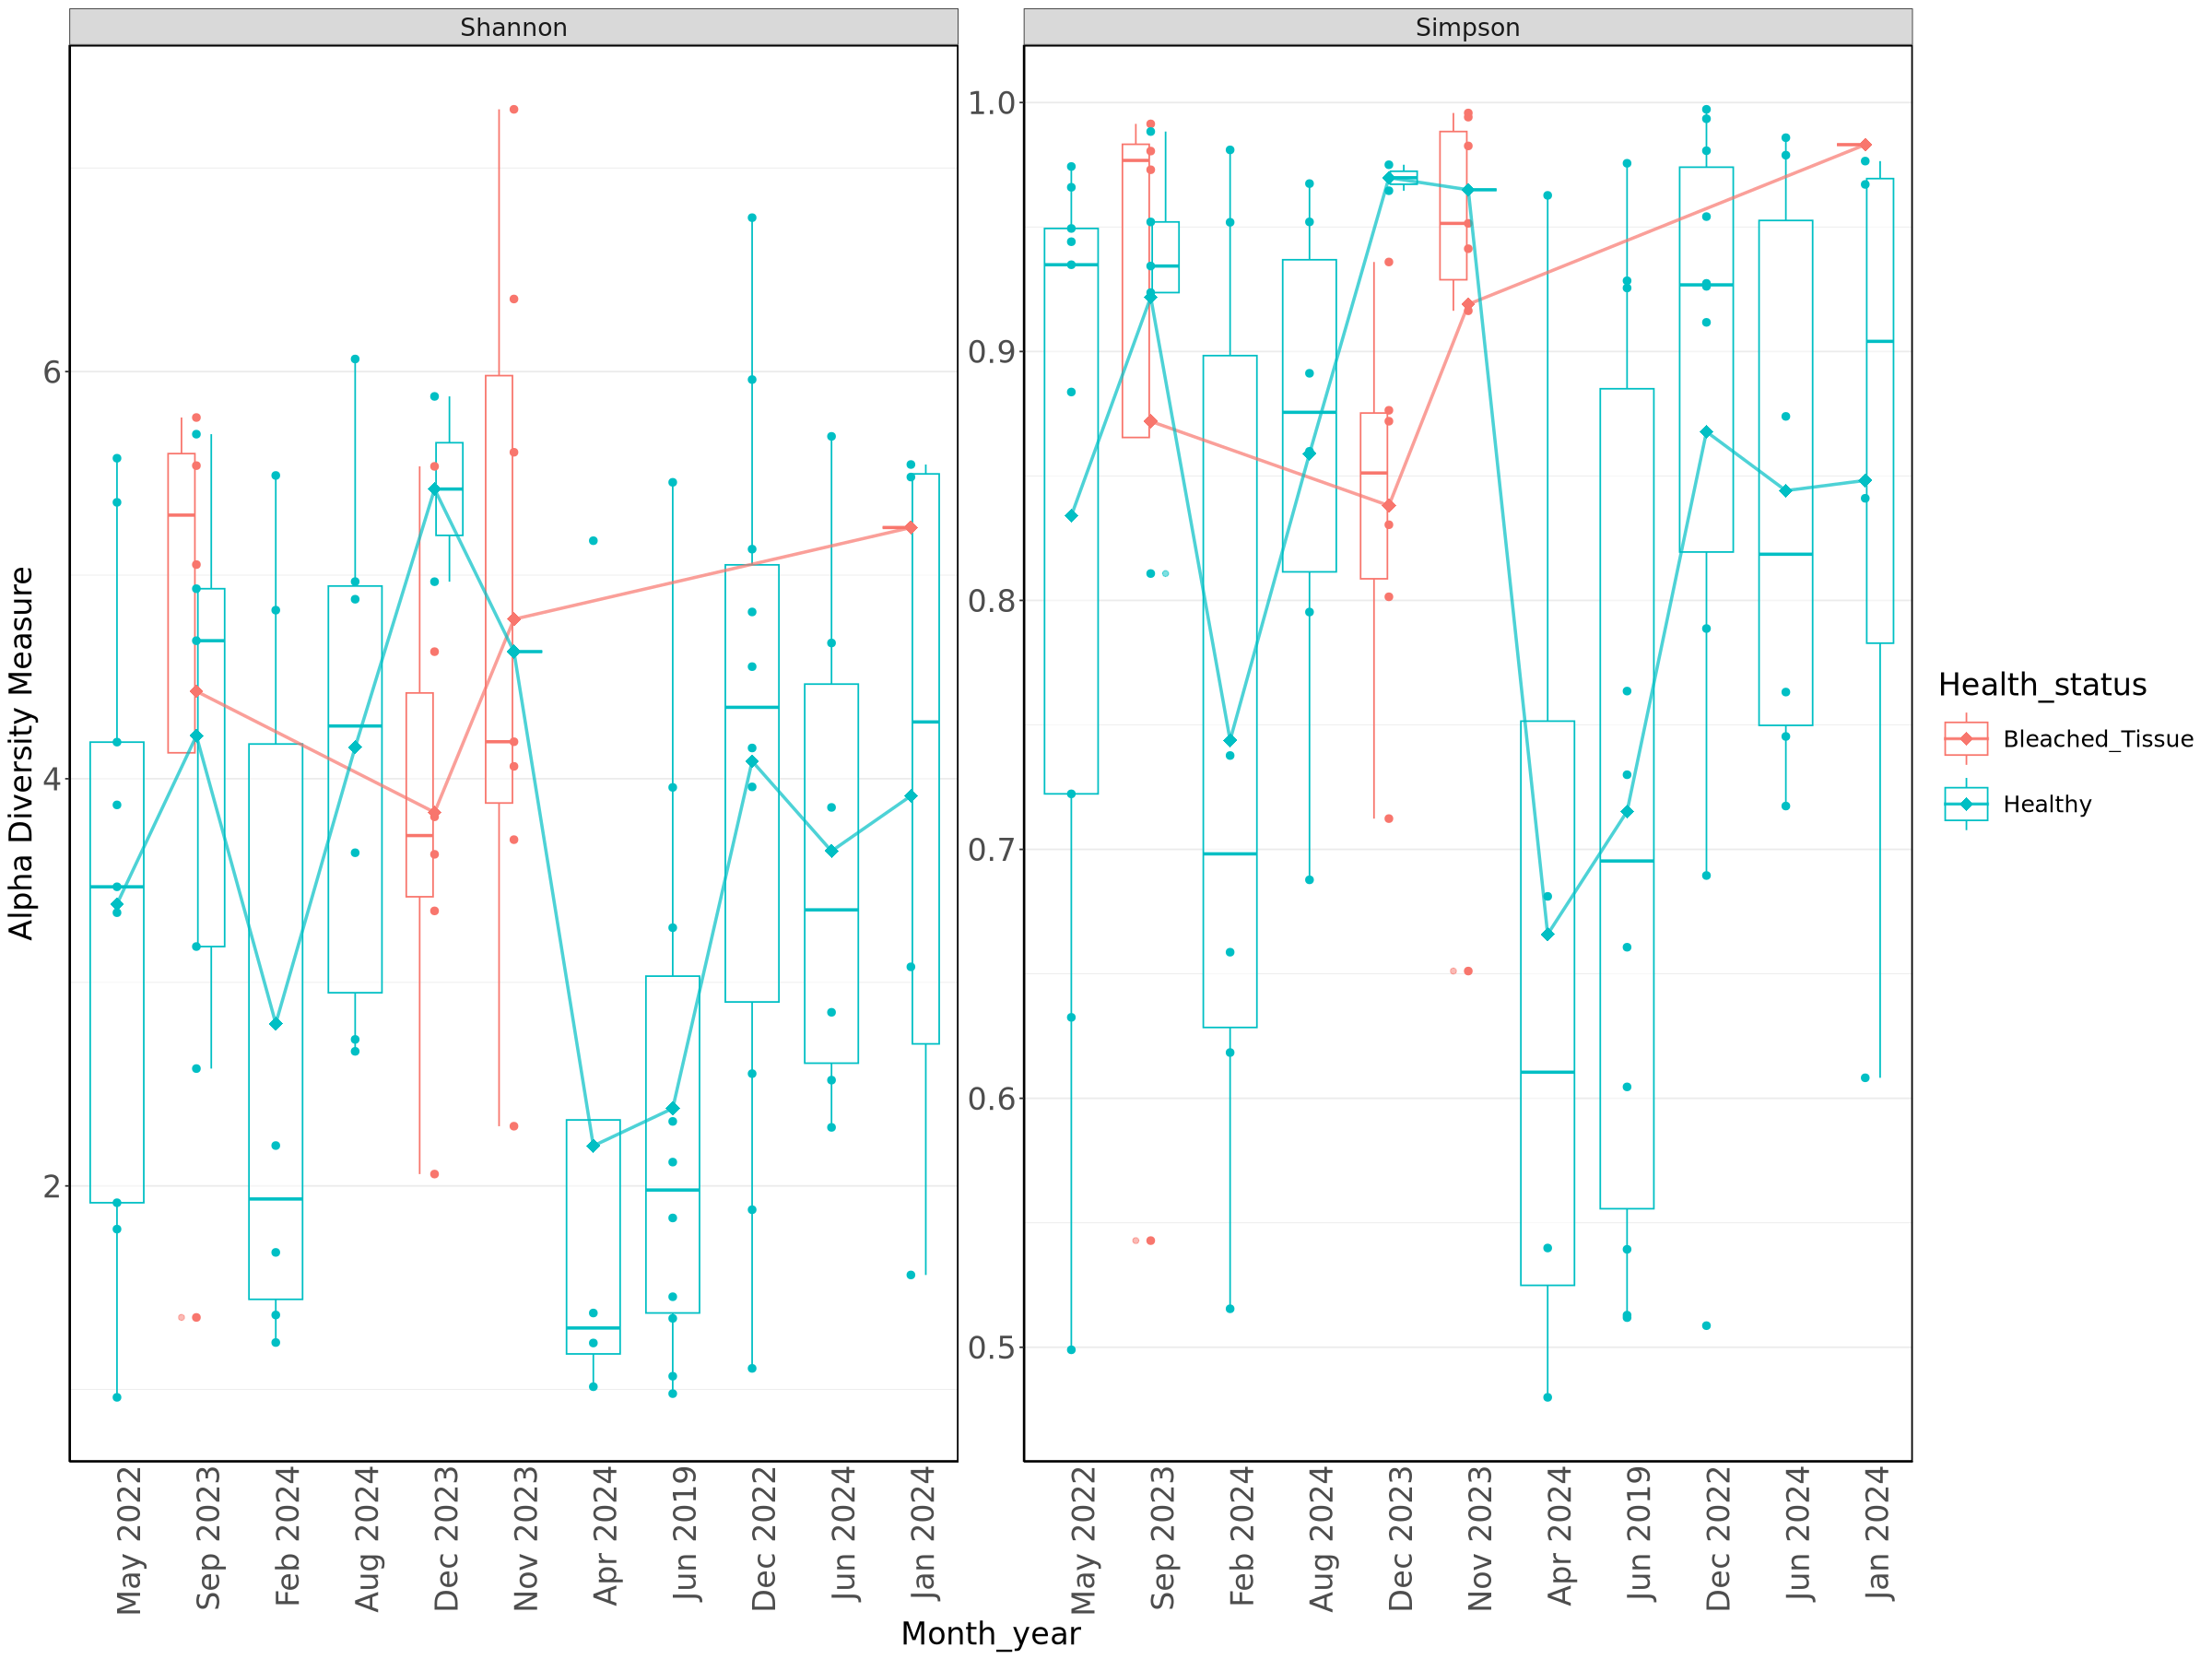

In [9]:
# Alpha diversity dot-line plot
plot_richness(ps_prune, x="Month_year", measures=c("Shannon", "Simpson"), color="Health_status") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Health_status), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Health_status)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

## making ps object a vegan compatible function

In [10]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_prune)$Month_year <- factor(sample_data(ps_prune)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


In [11]:
pssd2veg <- function(ps_prune) {
  sd_nomit <- sample_data(ps_prune)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_prune)

sample_nomit <- as.data.frame(sample_data(ps_prune))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

## only include repeated PAST colonies

In [12]:
# Return names which have more than one row of data
# Now filter
colonies <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#difference bw og and repeated colonies df
nrow(sample_nomit)
nrow(colonies)

#how many colonies
length(unique(colonies$colony))

[1] 81

[1] 81

[1] 10

In [13]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
#check
head(rownames(colonies))
nrow(sample_data(ps_prune))
head(colonies)

Warning message:
“Setting row names on a tibble is deprecated.”


[1] "092023_BEL_CBC_T1_175_PAST"  "042024_BEL_CBC_T2_1018_PAST"
[3] "052022_BEL_CBC_T3_11_PAST"   "052022_BEL_CBC_T3_8_PAST"   
[5] "122022_BEL_CBC_T3_123_PAST"  "052022_BEL_CBC_T2_9_PAST"

[1] 81

Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,SampleID
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>
Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST,092023_BEL_CBC_T1_175_PAST
Healthy,2_57,1_23_2025,Healthy,PAST,Apr 2024,1,SR30N,2024-04-26,042024_BEL_CBC_T2_1018_PAST,042024_BEL_CBC_T2_1018_PAST
Healthy,3_6,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_11_PAST,052022_BEL_CBC_T3_11_PAST
Healthy,3_10,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_8_PAST,052022_BEL_CBC_T3_8_PAST
Healthy,3_10,2_24_2025,Healthy,PAST,Dec 2022,1,Lagoon,2022-12-03,122022_BEL_CBC_T3_123_PAST,122022_BEL_CBC_T3_123_PAST
Healthy,2_63,2_24_2025,Healthy,PAST,May 2022,1,SR30N,2022-05-22,052022_BEL_CBC_T2_9_PAST,052022_BEL_CBC_T2_9_PAST


In [14]:
colonies <- as.data.frame(colonies)
class(colonies)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

In [15]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
head(colonies)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,SampleID
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST,092023_BEL_CBC_T1_175_PAST
042024_BEL_CBC_T2_1018_PAST,Healthy,2_57,1_23_2025,Healthy,PAST,Apr 2024,1,SR30N,2024-04-26,042024_BEL_CBC_T2_1018_PAST,042024_BEL_CBC_T2_1018_PAST
052022_BEL_CBC_T3_11_PAST,Healthy,3_6,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_11_PAST,052022_BEL_CBC_T3_11_PAST
052022_BEL_CBC_T3_8_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_8_PAST,052022_BEL_CBC_T3_8_PAST
122022_BEL_CBC_T3_123_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,Dec 2022,1,Lagoon,2022-12-03,122022_BEL_CBC_T3_123_PAST,122022_BEL_CBC_T3_123_PAST
052022_BEL_CBC_T2_9_PAST,Healthy,2_63,2_24_2025,Healthy,PAST,May 2022,1,SR30N,2022-05-22,052022_BEL_CBC_T2_9_PAST,052022_BEL_CBC_T2_9_PAST


## add new column in colonies that labels whether a colony was ever bleached or ever paled

In [16]:
## how many colonies only ever experienced paling?
paling_only_count <- colonies %>%
  group_by(colony) %>%
  summarize(
    ever_paled = any(Condition == "CLP"),
    ever_fully_bleached = any(Condition %in% c("CLP,CLB", "CLB"))
  ) %>%
  # Filter for colonies that paled, but NEVER fully bleached
  filter(ever_paled == TRUE & ever_fully_bleached == FALSE) %>% 
  nrow()

print(paling_only_count)

[1] 2


**using suseptible, intermediate and resistant to ID coral resisilience to bleaching**

In [17]:
#group by colony
colony_history <- colonies %>%
  group_by(colony) %>%
  summarize(
    # ever_bleached strictly means it hit full bleaching (CLB or CLP,CLB)
    ever_bleached = any(grepl("CLB", Condition)),
    
    # only_paled means it had CLP, but NEVER progressed to having CLB
    only_paled    = any(grepl("CLP", Condition)) & !ever_bleached
  )

# The rest of your labeling and arranging code works exactly the same:
colony_order_df <- colony_history %>%
  arrange(desc(ever_bleached), desc(only_paled), colony) %>%
  mutate(colony_label = case_when(
    ever_bleached == TRUE ~ paste(colony, "(Suseptible)"),
    only_paled    == TRUE ~ paste(colony, "(Intermediate)"),
    TRUE                  ~ as.character(colony, "(Resistant"),
  ))

# 3. Extract your vectors
ordered_colonies <- colony_order_df$colony
ordered_labels   <- colony_order_df$colony_label

## create ps_col with colonies dataframe

In [18]:
keep_samples <- rownames(colonies)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm
sum(keep_samples %in% sample_names(ps_prune))  # Should be 81

[1] 81

[1] 81

In [19]:
# check they are the same rownames
head(sample_names(ps_prune))
head(keep_samples)

[1] "092023_BEL_CBC_T1_175_PAST"  "042024_BEL_CBC_T2_1018_PAST"
[3] "052022_BEL_CBC_T3_11_PAST"   "052022_BEL_CBC_T3_8_PAST"   
[5] "122022_BEL_CBC_T3_123_PAST"  "052022_BEL_CBC_T2_9_PAST"

[1] "092023_BEL_CBC_T1_175_PAST"  "042024_BEL_CBC_T2_1018_PAST"
[3] "052022_BEL_CBC_T3_11_PAST"   "052022_BEL_CBC_T3_8_PAST"   
[5] "122022_BEL_CBC_T3_123_PAST"  "052022_BEL_CBC_T2_9_PAST"

In [20]:
# Prune to keep only those samples
ps_col <- prune_samples(sample_names(ps_prune) %in% keep_samples, ps_prune)
ps_col

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 25905 taxa and 81 samples ]
sample_data() Sample Data:       [ 81 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 25905 taxa by 6 taxonomic ranks ]

In [21]:
## check up on ps_col
class(ps_col)
nrow(sample_data(ps_col))

all(rownames(colonies) %in% sample_names(ps_col))
head(sample_data(ps_col))

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] 81

[1] TRUE

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST
042024_BEL_CBC_T2_1018_PAST,Healthy,2_57,1_23_2025,Healthy,PAST,Apr 2024,1,SR30N,2024-04-26,042024_BEL_CBC_T2_1018_PAST
052022_BEL_CBC_T3_11_PAST,Healthy,3_6,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_11_PAST
052022_BEL_CBC_T3_8_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_8_PAST
122022_BEL_CBC_T3_123_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,Dec 2022,1,Lagoon,2022-12-03,122022_BEL_CBC_T3_123_PAST
052022_BEL_CBC_T2_9_PAST,Healthy,2_63,2_24_2025,Healthy,PAST,May 2022,1,SR30N,2022-05-22,052022_BEL_CBC_T2_9_PAST


## reorder ps_col
- dates in chronological order
- colonies by whether they were bleached or only paled

In [22]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_col)$Month_year <- factor(sample_data(ps_col)$Month_year,levels = c("Jun 2019","May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


In [23]:
# adding diseased vs bleached labels to facets

#create new col colony_labeled 

current_colonies <- sample_data(ps_col)$colony

# Create a column in sample_data(ps_col) where the disease, CLB, CLp VALUES are the labels, but the LEVELS dictate the order
sample_data(ps_col)$colony_labeled <- factor(
  colony_order_df$colony_label[match(current_colonies, colony_order_df$colony)],
  levels = ordered_labels
)

In [54]:
head(sample_data(ps_col))

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,colony_labeled
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<fct>
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST,1_13
042024_BEL_CBC_T2_1018_PAST,Healthy,2_57,1_23_2025,Healthy,PAST,Apr 2024,1,SR30N,2024-04-26,042024_BEL_CBC_T2_1018_PAST,2_57 (Bleached)
052022_BEL_CBC_T3_11_PAST,Healthy,3_6,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_11_PAST,3_6 (Bleached)
052022_BEL_CBC_T3_8_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_8_PAST,3_10 (Bleached)
122022_BEL_CBC_T3_123_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,Dec 2022,1,Lagoon,2022-12-03,122022_BEL_CBC_T3_123_PAST,3_10 (Bleached)
052022_BEL_CBC_T2_9_PAST,Healthy,2_63,2_24_2025,Healthy,PAST,May 2022,1,SR30N,2022-05-22,052022_BEL_CBC_T2_9_PAST,2_63 (Bleached)


## stats
- what are the most prevalent 
- which bacteria are most common across transect and health status

In [24]:
# Calculate prevalence of specific taxa (number of samples with count > 0)
prev_df <- apply(X = otu_table(ps_col),
                 MARGIN = ifelse(taxa_are_rows(ps_col), 1, 2),
                 FUN = function(x){sum(x > 0)})
# Add taxonomy for better identification
prev_df <- data.frame(Prevalence = prev_df,
                      Taxa_Names = taxa_names(ps_col),
                      tax_table(ps_col))
# Rank by prevalence
head(prev_df[order(-prev_df$Prevalence), ])

,Prevalence,Taxa_Names,Kingdom,Phylum,Class,Order,Family,Genus
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,81,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCACGTAGGCGGATCGGAAAGTTGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCTCCAAAACTATCGGTCTAGAGTTCGAGAGAGGTGAGTGGAATTCCGAGTGTAGAGGTGAAATTCGTAGATATTCGGAGGAACACCAGTGGCGAAGGCGGCTCACTGGCTCGATACTGACGCTGAGGTGCGAAAGTGTGGGG,79,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCACGTAGGCGGATCGGAAAGTTGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCTCCAAAACTATCGGTCTAGAGTTCGAGAGAGGTGAGTGGAATTCCGAGTGTAGAGGTGAAATTCGTAGATATTCGGAGGAACACCAGTGGCGAAGGCGGCTCACTGGCTCGATACTGACGCTGAGGTGCGAAAGTGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Paracoccaceae,Ruegeria
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,76,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,72,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGCGGCTTGTTAAGCCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGGAACTGGCAGGCTAGAGTCTTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGATGCGAAAGCGTGGGG,72,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGCGGCTTGTTAAGCCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGGAACTGGCAGGCTAGAGTCTTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGATGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Photobacterium
GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGACTATCAAGTCAGAGGTGAAAGCCCCGGGCTCAACCTGGGAACTGCCTTTGAAACTGATAGACTAGAGTCCGGAAGAGGATAGCGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCAGTGGCGAAGGCGGCTATCTGGTCCGGTACTGACGCTGAGGCGCGAAAGCGTGGGG,72,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGACTATCAAGTCAGAGGTGAAAGCCCCGGGCTCAACCTGGGAACTGCCTTTGAAACTGATAGACTAGAGTCCGGAAGAGGATAGCGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCAGTGGCGAAGGCGGCTATCTGGTCCGGTACTGACGCTGAGGCGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,Kiloniellales,Kiloniellaceae,Thalassocola


## diversity plots
- unnormalized

# alpha diversity
- null hypothesis: microbiome diversity in coral colonies has changed over time
- null hypothesis: not all transects have equal diversity

**looks the same as ps_prune alpha diversity plot. GREAT!**

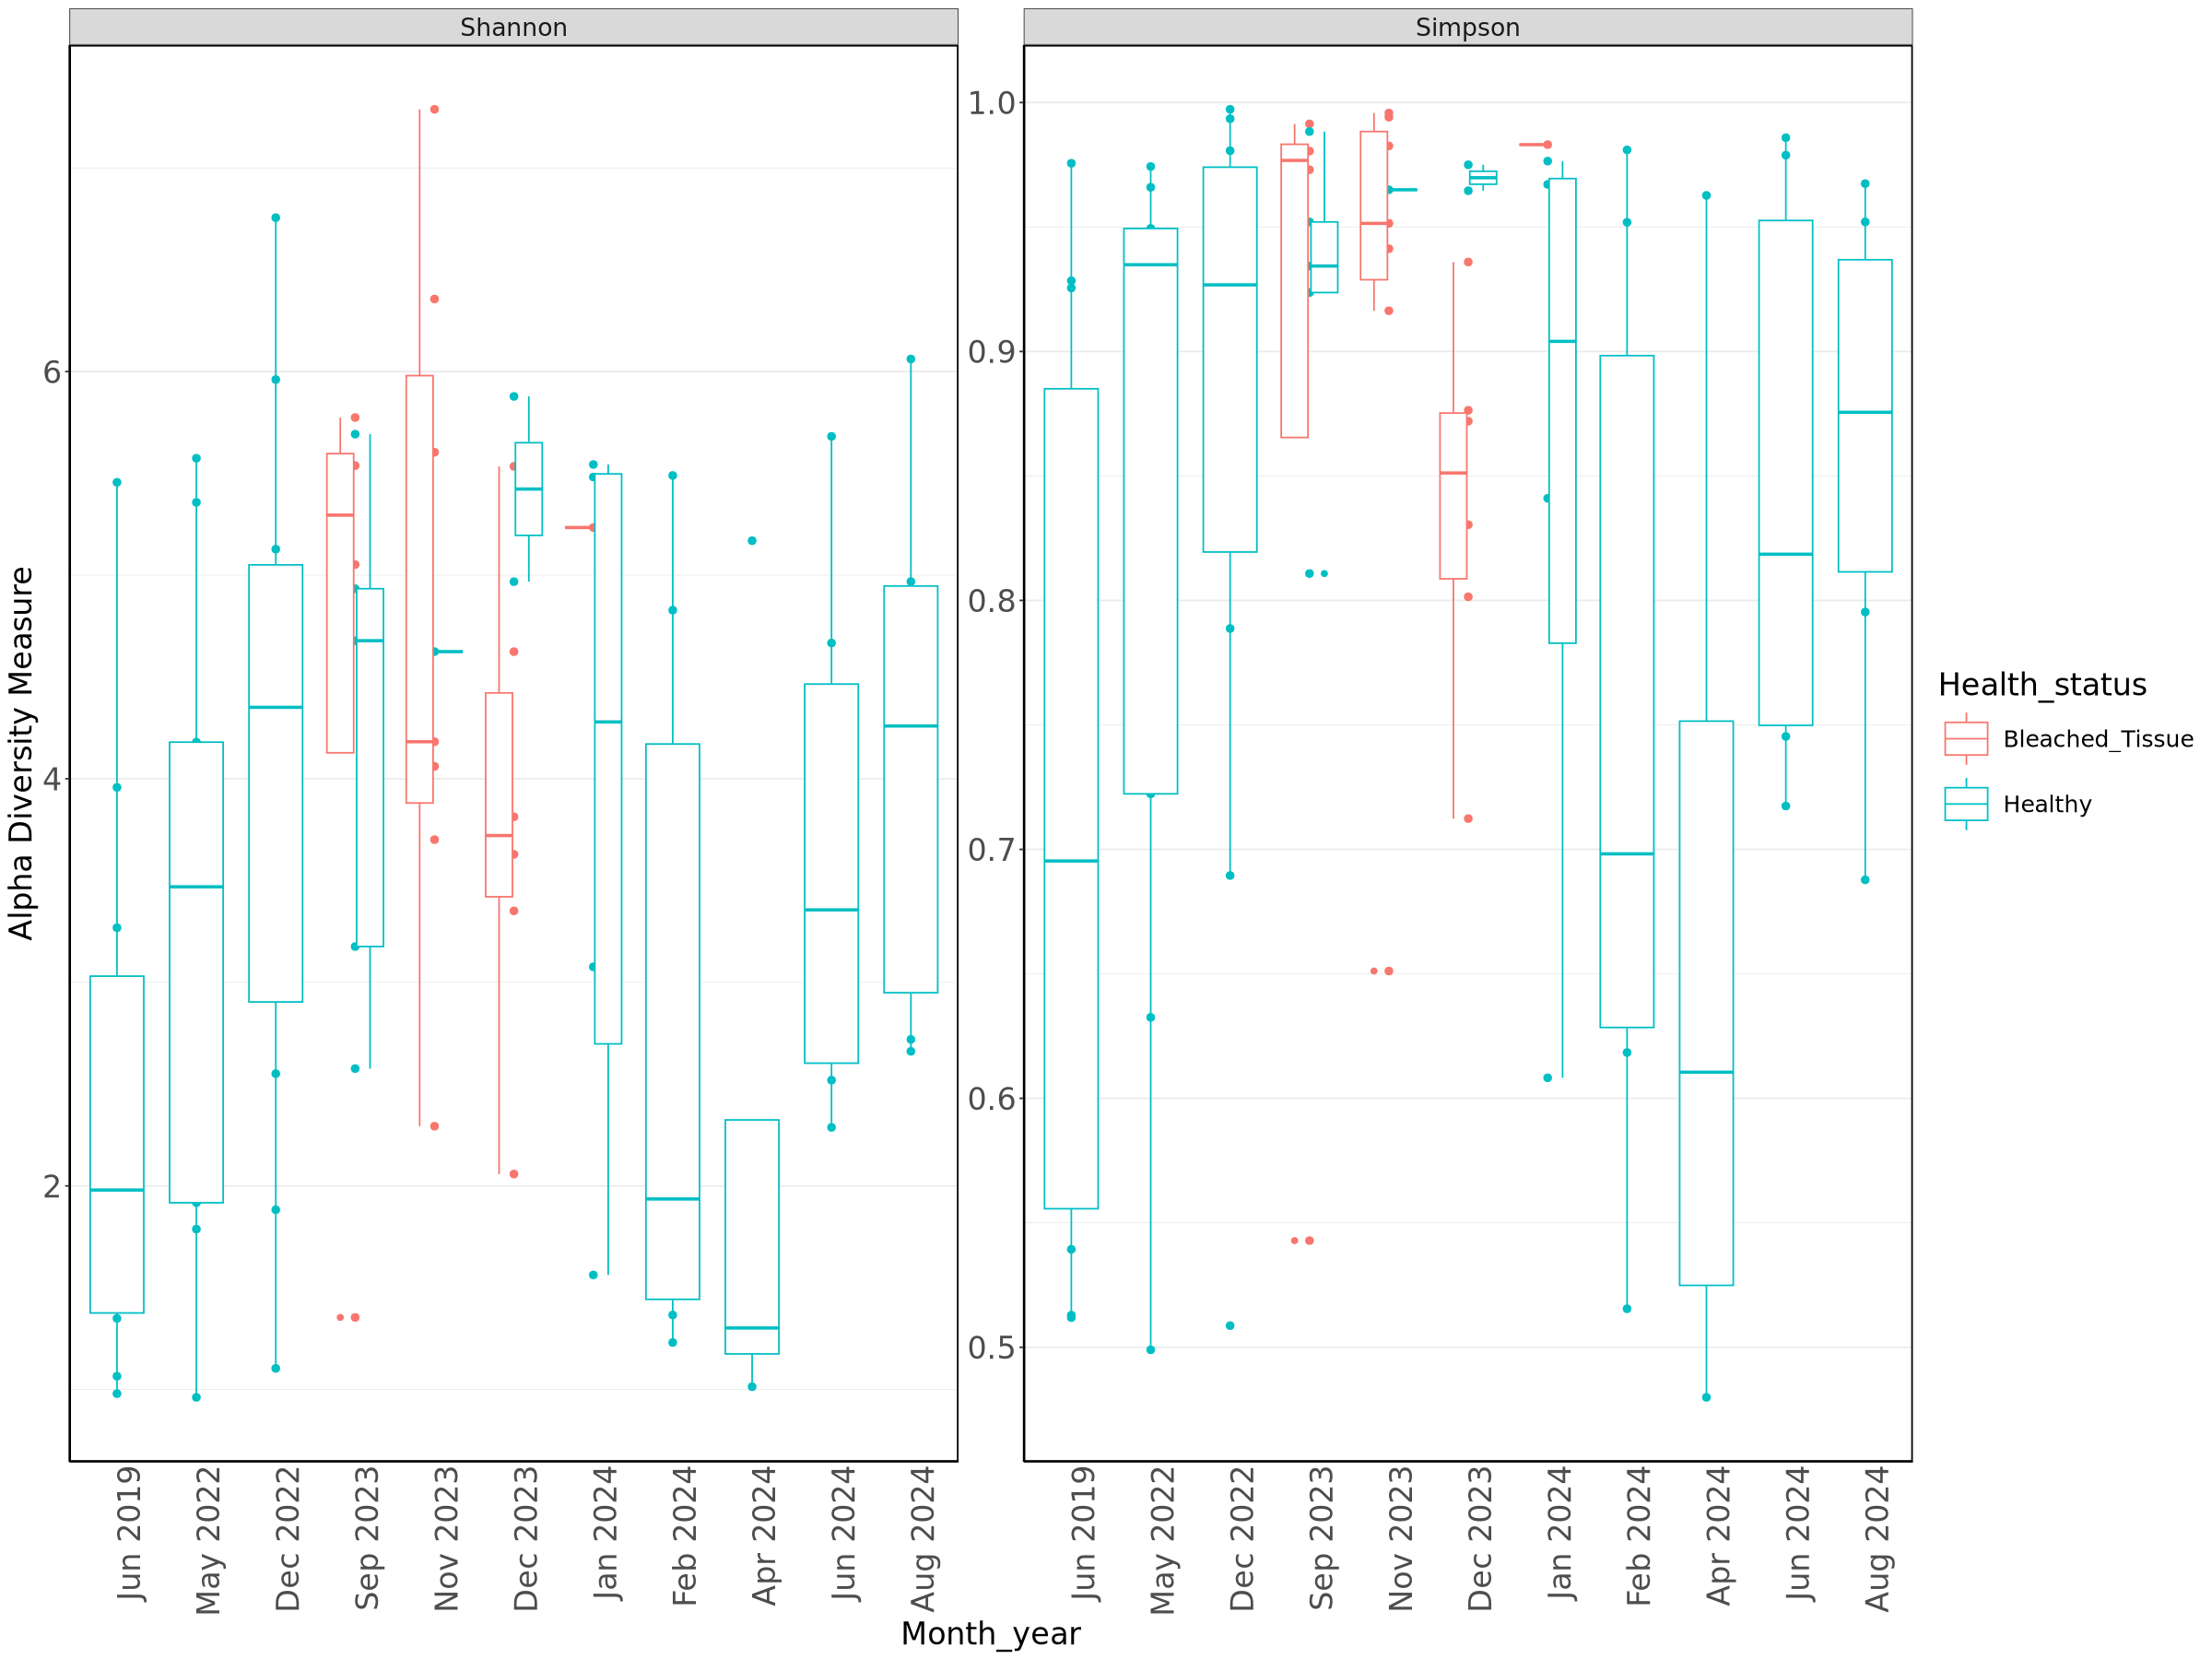

In [25]:
# box plots

plot_richness(ps_col, x="Month_year", measures=c("Shannon", "Simpson"), color="Health_status") + 
geom_point(size=2) +
geom_boxplot() +
theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

### figure notes
- the above figure shows how alpha diversity shifts in P. asteroides (on different scales depending on Shannon or simpson calculations)
- We can see some shifts in alpha diversity overtime. For example we see that PAST colonies in all 3 reefs showed higher bacterial community diversity during the 2023 bleaching event (peak dievrsity in Nov 2023)
- After Nov 2023, diversity in SR30N and CBC30N began recovering in June 2024. In contrast PAST colonies at Lagoon experienced a boom in bacterial community diversity after bleaching 2023.

In [26]:
## but could the increased diversity be due to the fact that only 3/5 colonies from lagoon were sampled during NSF rapid?

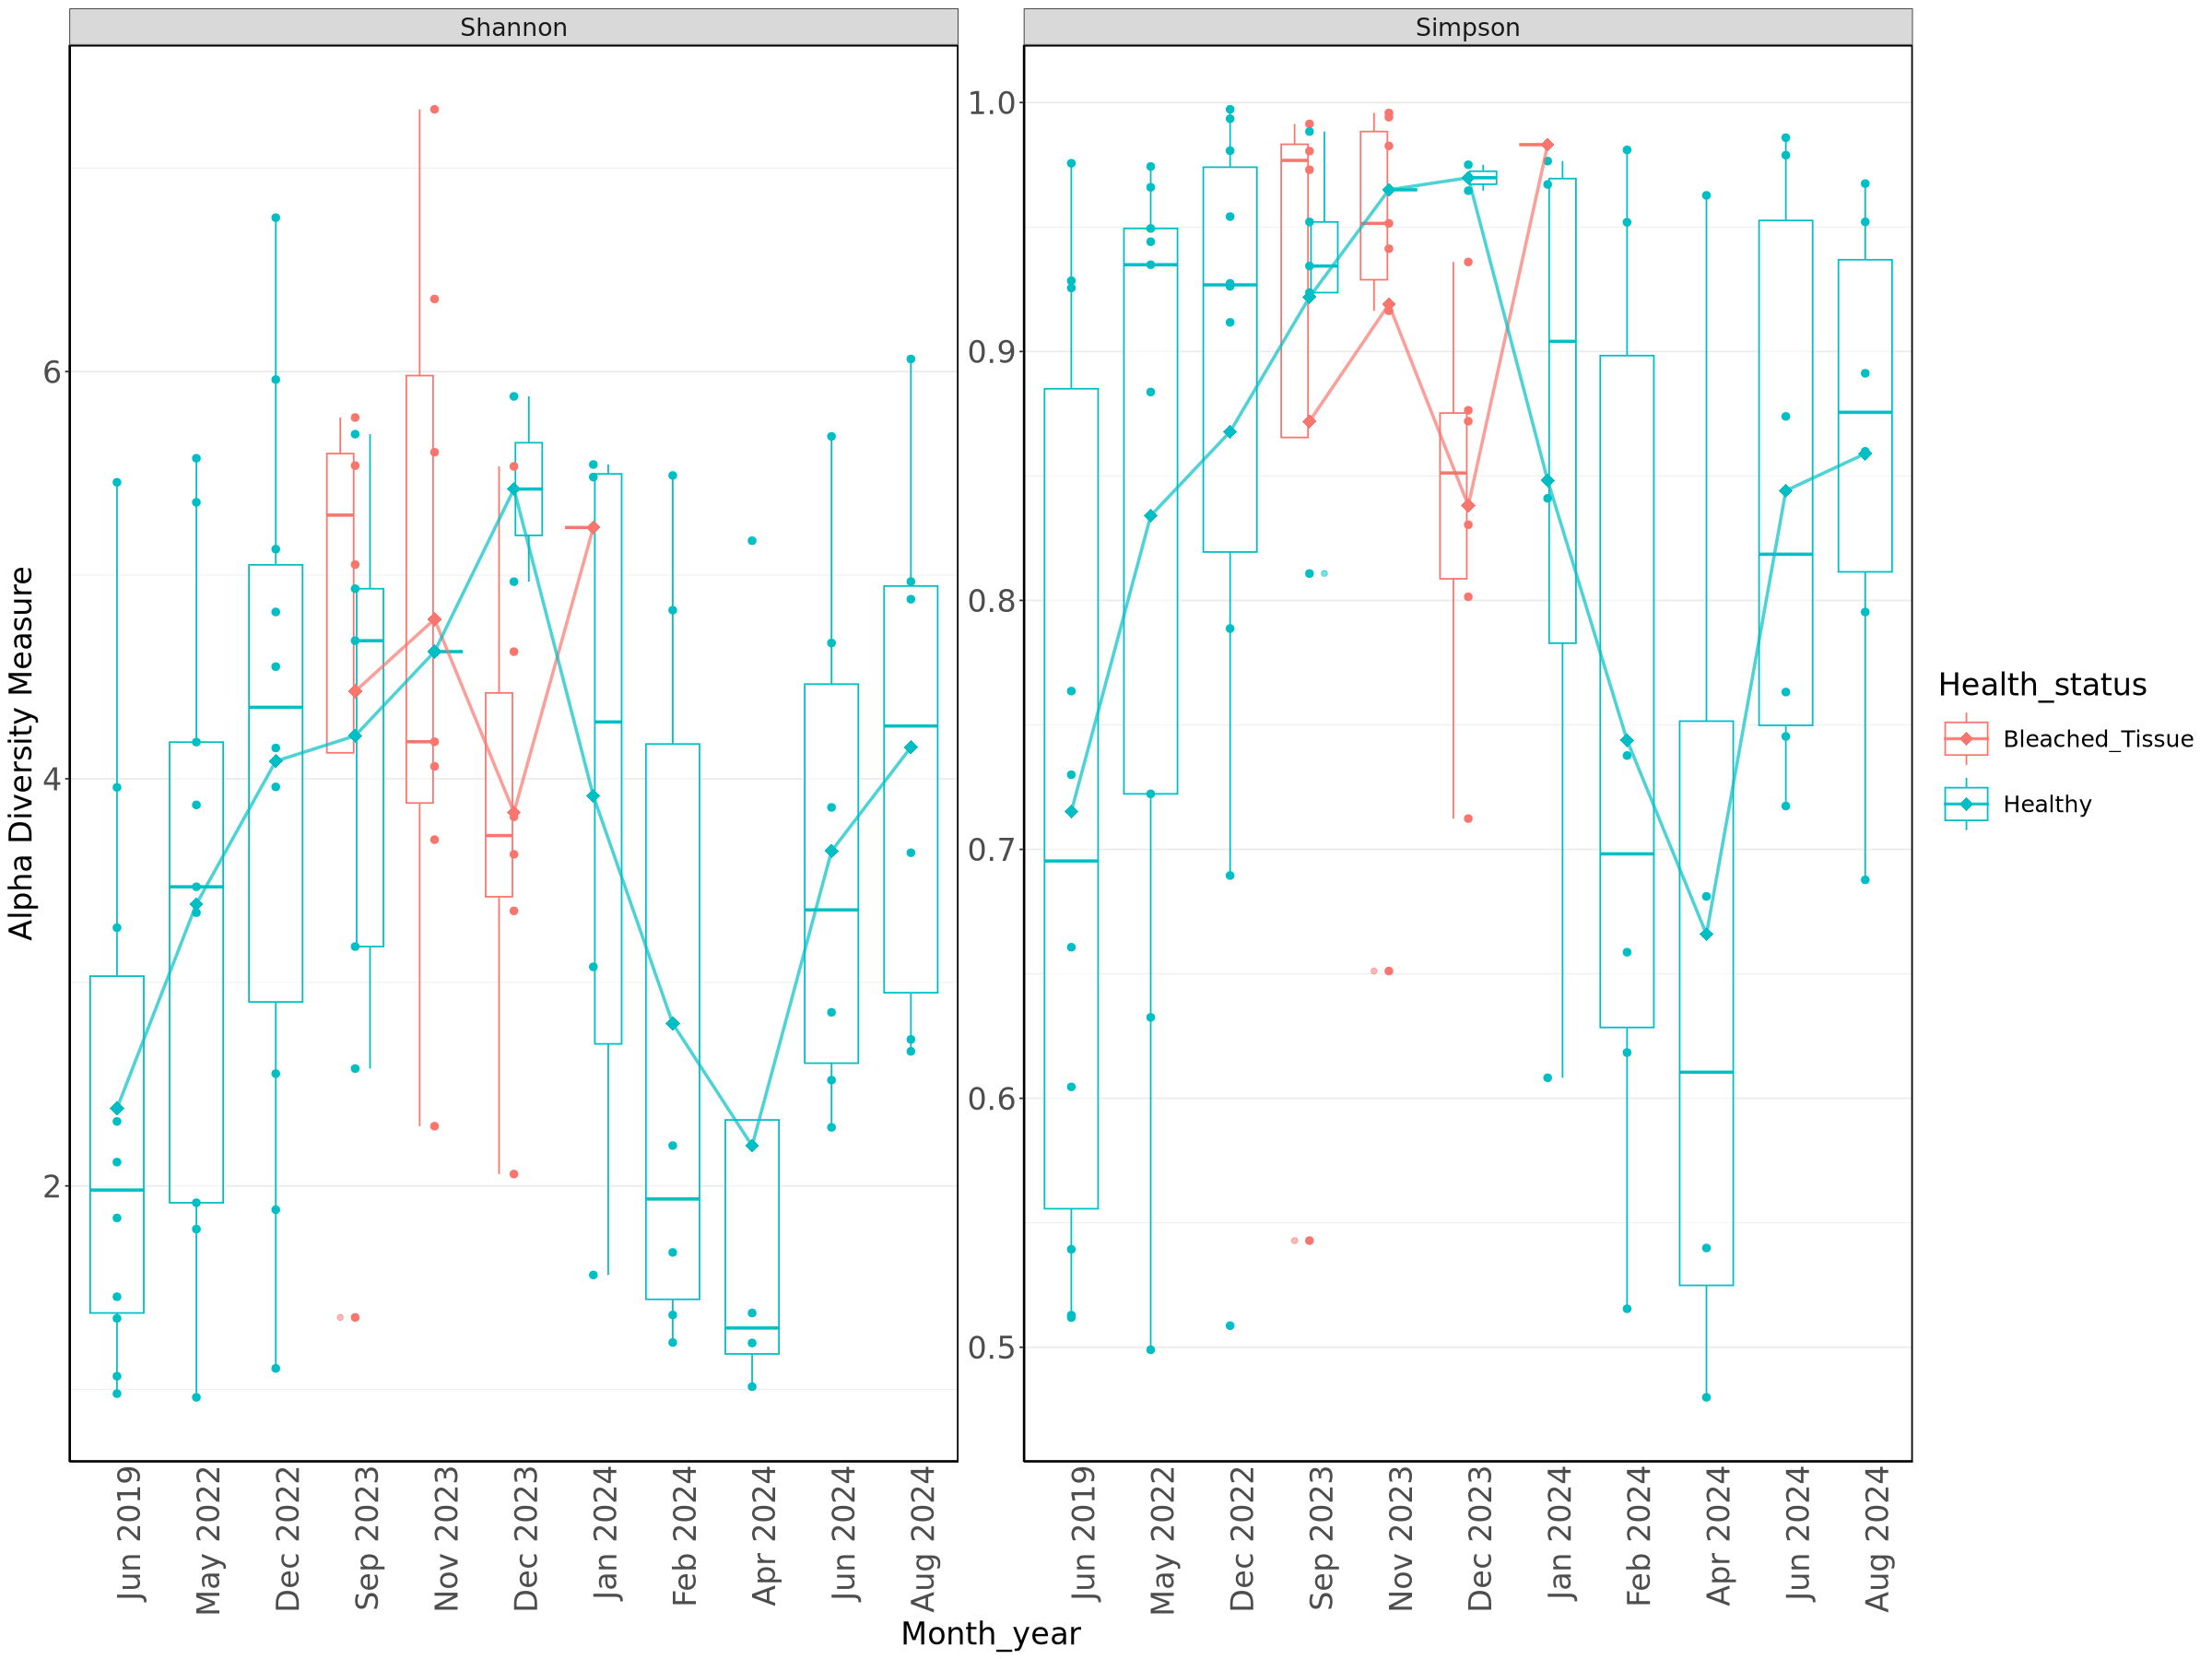

In [27]:
# Alpha diversity dot-line plot
plot_richness(ps_col, x="Month_year", measures=c("Shannon", "Simpson"), color="Health_status") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Health_status), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Health_status)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

# taxonomy plots prep
- how many bacterial communities should I let through?
    - 300
    - 100
    - 25
- what level should I show? order, Family, Genus?

### normalize for 16S taxonomy plots

In [84]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_col, function(x) 1E6 * x / sum(x))

### the number of samples in which a taxon appears at least once.
- most common otus for PAST are two endozoicomonadacae and two vibrionacae

In [85]:
# Calculate prevalence of specific taxa (number of samples with count > 0)
prevalence_all <- apply(X = otu_table(ps_norm),
                 MARGIN = ifelse(taxa_are_rows(ps_norm), 1, 2),
                 FUN = function(x){sum(x > 0)})
# Add taxonomy for better identification
prevalence_all <- data.frame(Prevalence = prevalence_all,
                      Taxa_Names = taxa_names(ps_norm),
                      tax_table(ps_norm))
# Rank by prevalence
head(prevalence_all[order(-prevalence_all$Prevalence), ])

,Prevalence,Taxa_Names,Kingdom,Phylum,Class,Order,Family,Genus
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,81,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCACGTAGGCGGATCGGAAAGTTGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCTCCAAAACTATCGGTCTAGAGTTCGAGAGAGGTGAGTGGAATTCCGAGTGTAGAGGTGAAATTCGTAGATATTCGGAGGAACACCAGTGGCGAAGGCGGCTCACTGGCTCGATACTGACGCTGAGGTGCGAAAGTGTGGGG,79,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCACGTAGGCGGATCGGAAAGTTGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCTCCAAAACTATCGGTCTAGAGTTCGAGAGAGGTGAGTGGAATTCCGAGTGTAGAGGTGAAATTCGTAGATATTCGGAGGAACACCAGTGGCGAAGGCGGCTCACTGGCTCGATACTGACGCTGAGGTGCGAAAGTGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Paracoccaceae,Ruegeria
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,76,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,72,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGCGGCTTGTTAAGCCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGGAACTGGCAGGCTAGAGTCTTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGATGCGAAAGCGTGGGG,72,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGCGGCTTGTTAAGCCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGGAACTGGCAGGCTAGAGTCTTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGATGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Photobacterium
GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGACTATCAAGTCAGAGGTGAAAGCCCCGGGCTCAACCTGGGAACTGCCTTTGAAACTGATAGACTAGAGTCCGGAAGAGGATAGCGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCAGTGGCGAAGGCGGCTATCTGGTCCGGTACTGACGCTGAGGCGCGAAAGCGTGGGG,72,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGACTATCAAGTCAGAGGTGAAAGCCCCGGGCTCAACCTGGGAACTGCCTTTGAAACTGATAGACTAGAGTCCGGAAGAGGATAGCGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCAGTGGCGAAGGCGGCTATCTGGTCCGGTACTGACGCTGAGGCGCGAAAGCGTGGGG,Bacteria,Pseudomonadota,Alphaproteobacteria,Kiloniellales,Kiloniellaceae,Thalassocola


## colors for most common family taxa
- called famcolors use for all taxa plots

In [86]:


    # how many unique family taxa are there in ps_past?
length(unique(tax_table(ps_past)[, "Family"]))
length(unique(tax_table(ps_high)[, "Family"]))

length(unique(tax_table(ps_nomit)[, "Family"]))

length(unique(tax_table(ps_prune)[, "Family"]))

# how many unique fam taxa are there in ps_col?
length(unique(tax_table(ps_col)[, "Family"]))
    # how many unique family taxa are there in normalized
length(unique(tax_table(ps_norm)[, "Family"]))


[1] 483

[1] 483

[1] 469

[1] 412

[1] 412

[1] 412

In [87]:
#reduce that to top 50
ps_fam=tax_glom(ps_norm, taxrank= "Family")

top300 <- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:300] 
ps_fam300 <- prune_taxa(top300, ps_fam) 

In [88]:
### ps_fam100 colors

# --- 1. Get unique family cleanly as character strings ---
fam_300_names <- as.character(unique(tax_table(ps_fam300)[, "Family"]))

In [89]:
## try a larger range of colors

hues <- seq(15, 375, length.out = 300 + 1)[1:300]

# 1. Sine wave for Luminance: peaks at Yellow (90) and drops at Blue (270)
# This prevents yellow from clipping to green/brown!
l_vals <- 55 + 25 * sin((hues - 15) * pi / 180)

# 2. Alternating Chroma: high/low pattern so colors alternate between pastel & vibrant
# This keeps colors physically displayable on your screen (inside the RGB gamut)
c_vals <- rep(c(85, 45, 65), length.out = 36)

# 3. Generate your safe, broad-range colors
famcolors_ramp <- hcl(h = hues, c = c_vals, l = l_vals)

# 4. Shuffle reproducibly
# i like seet 6, 8
set.seed(13)
famcolors <- sample(famcolors_ramp)

# 5. Assign names
names(famcolors) <- fam_300_names

## top 300 PAST family over time
- facetted by colony

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


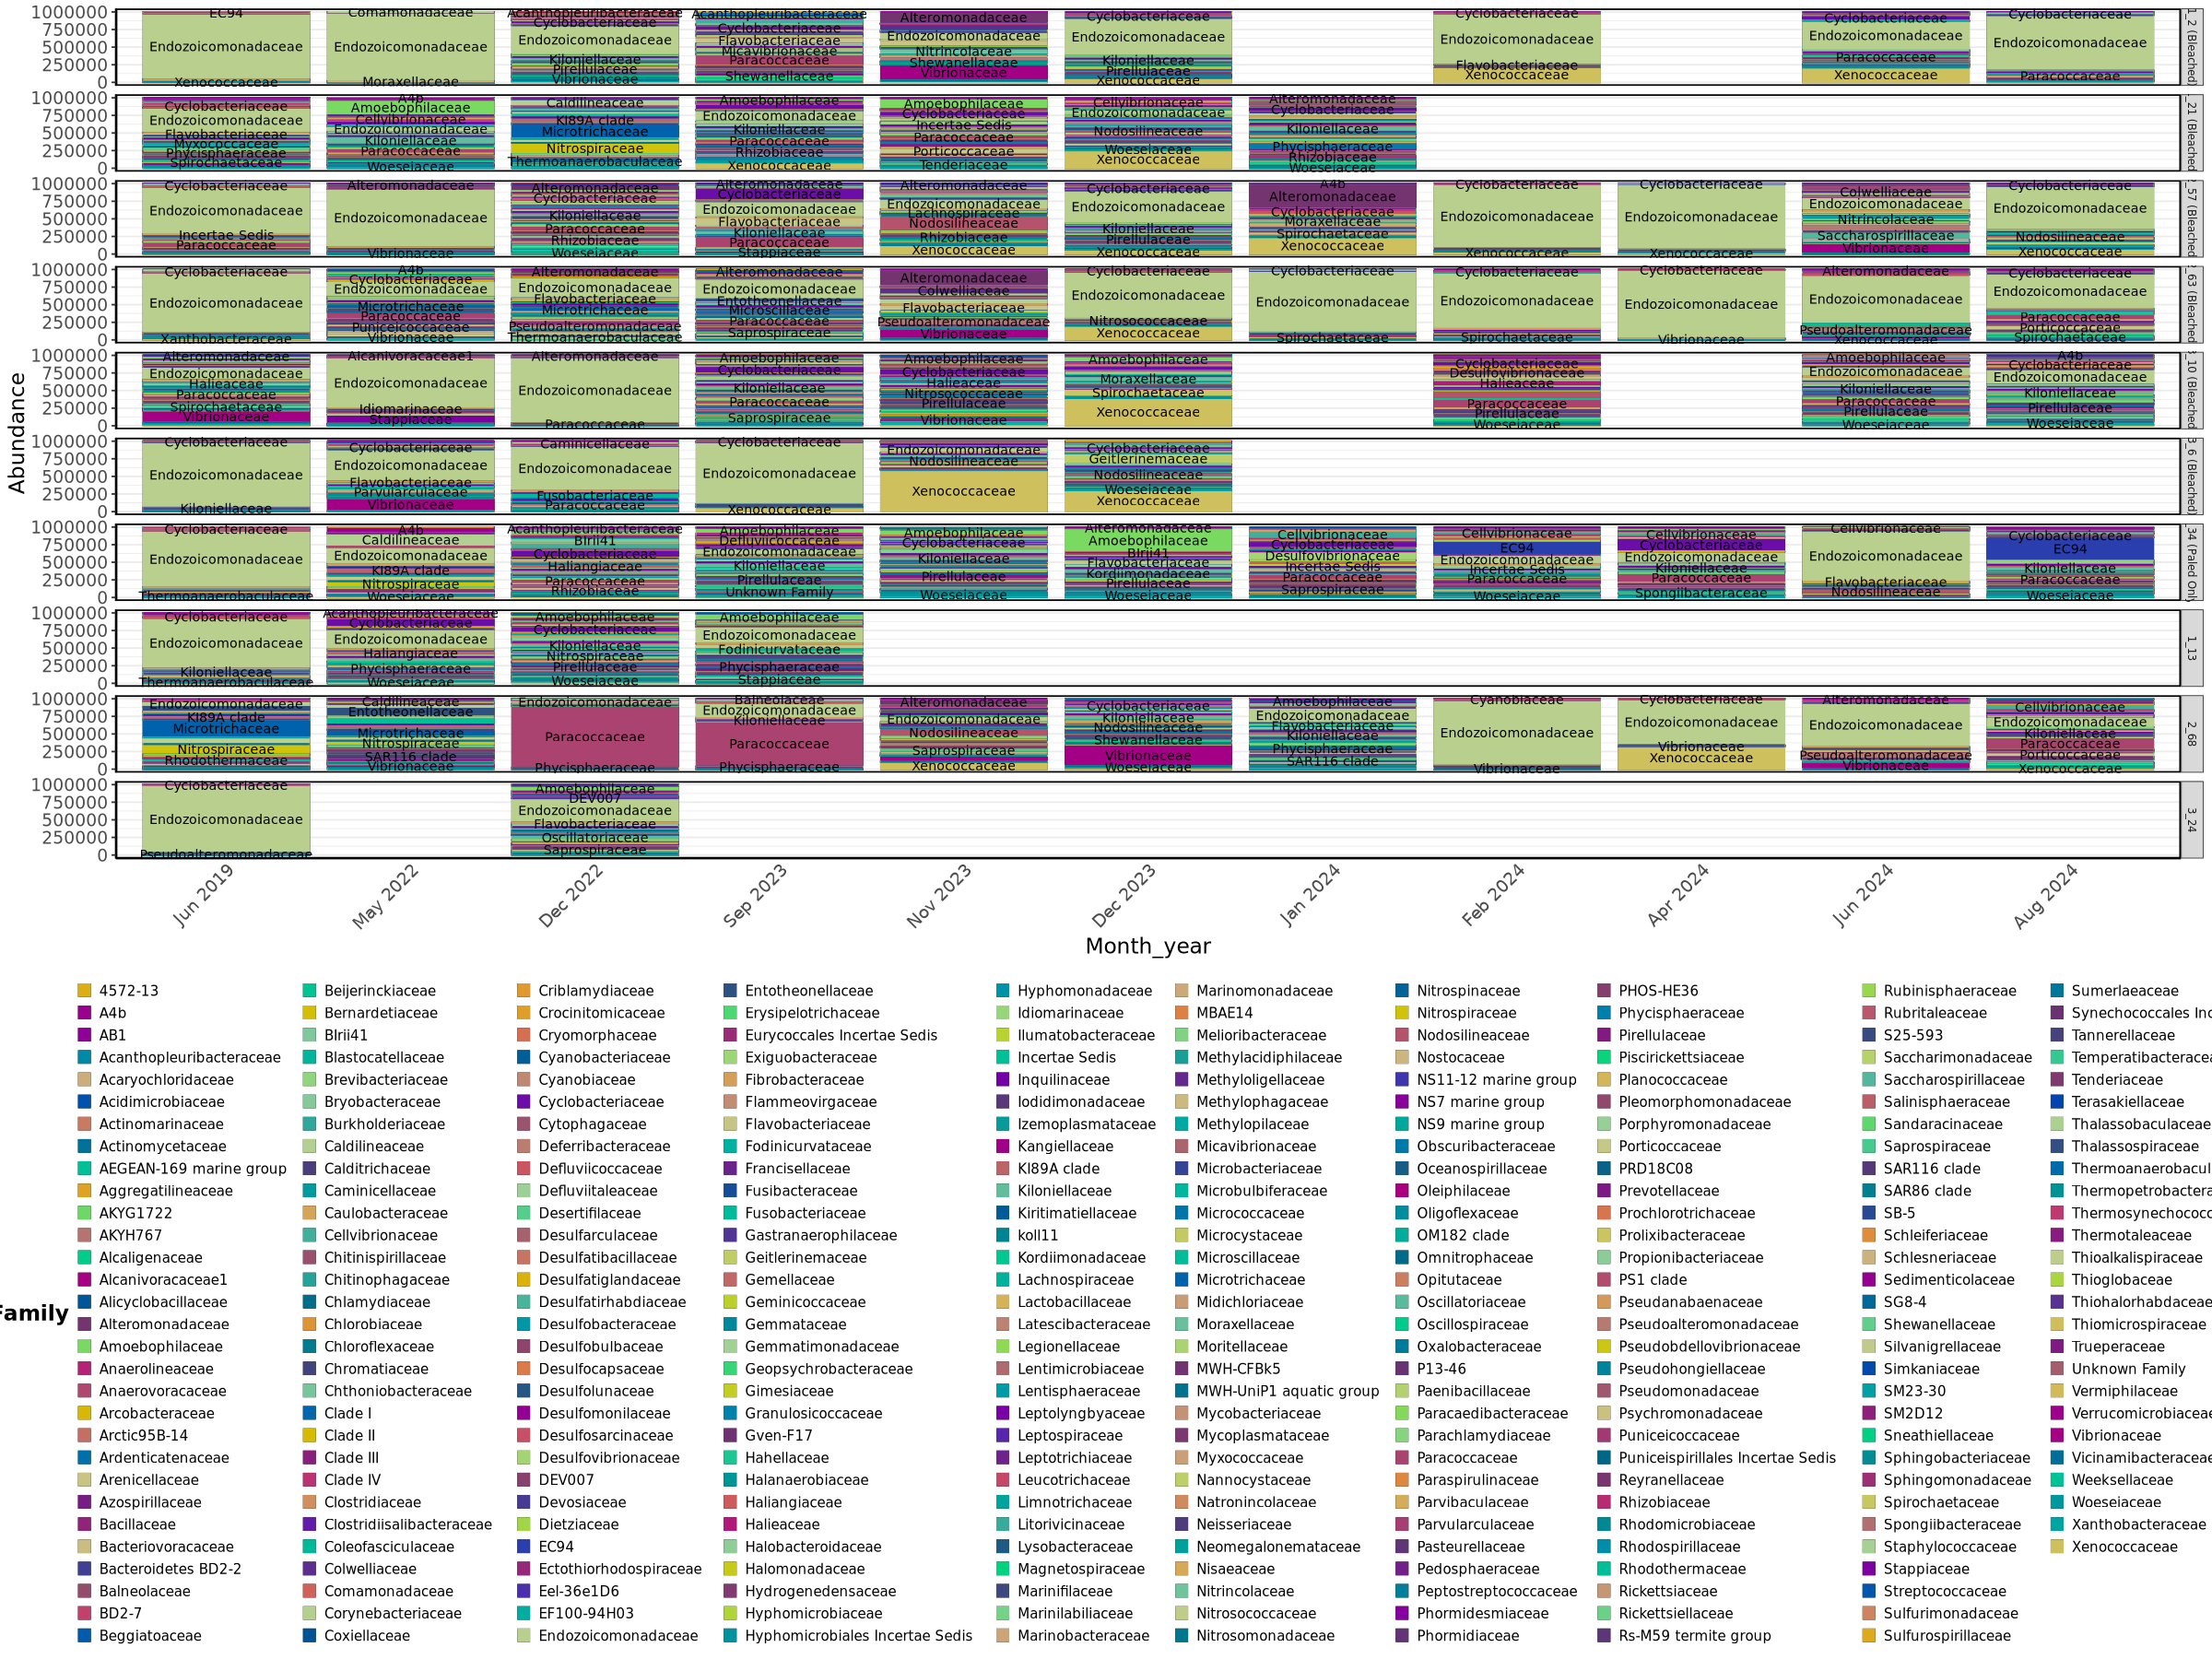

In [94]:
#plot
past_300 <- plot_bar(ps_fam300, x="Month_year", fill = "Family") +
  facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 3, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    # Move legend to the bottom so the plot gets maximum width
    legend.position = "bottom",
    legend.box = "horizontal",
    
    # Scale down text & key sizes so it doesn't crowd out the plot vertically
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 9),
    legend.key.width = unit(0.3, "cm"),     
    legend.key.height = unit(0.3, "cm"),   
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 14), 
      strip.text = element_text(size = 7) # Alters only the facet font size
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 10, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 10)
  )
past_300

## top 100 family taxa

In [96]:
top100 <- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:100] 
ps_fam100 <- prune_taxa(top100, ps_fam) 

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


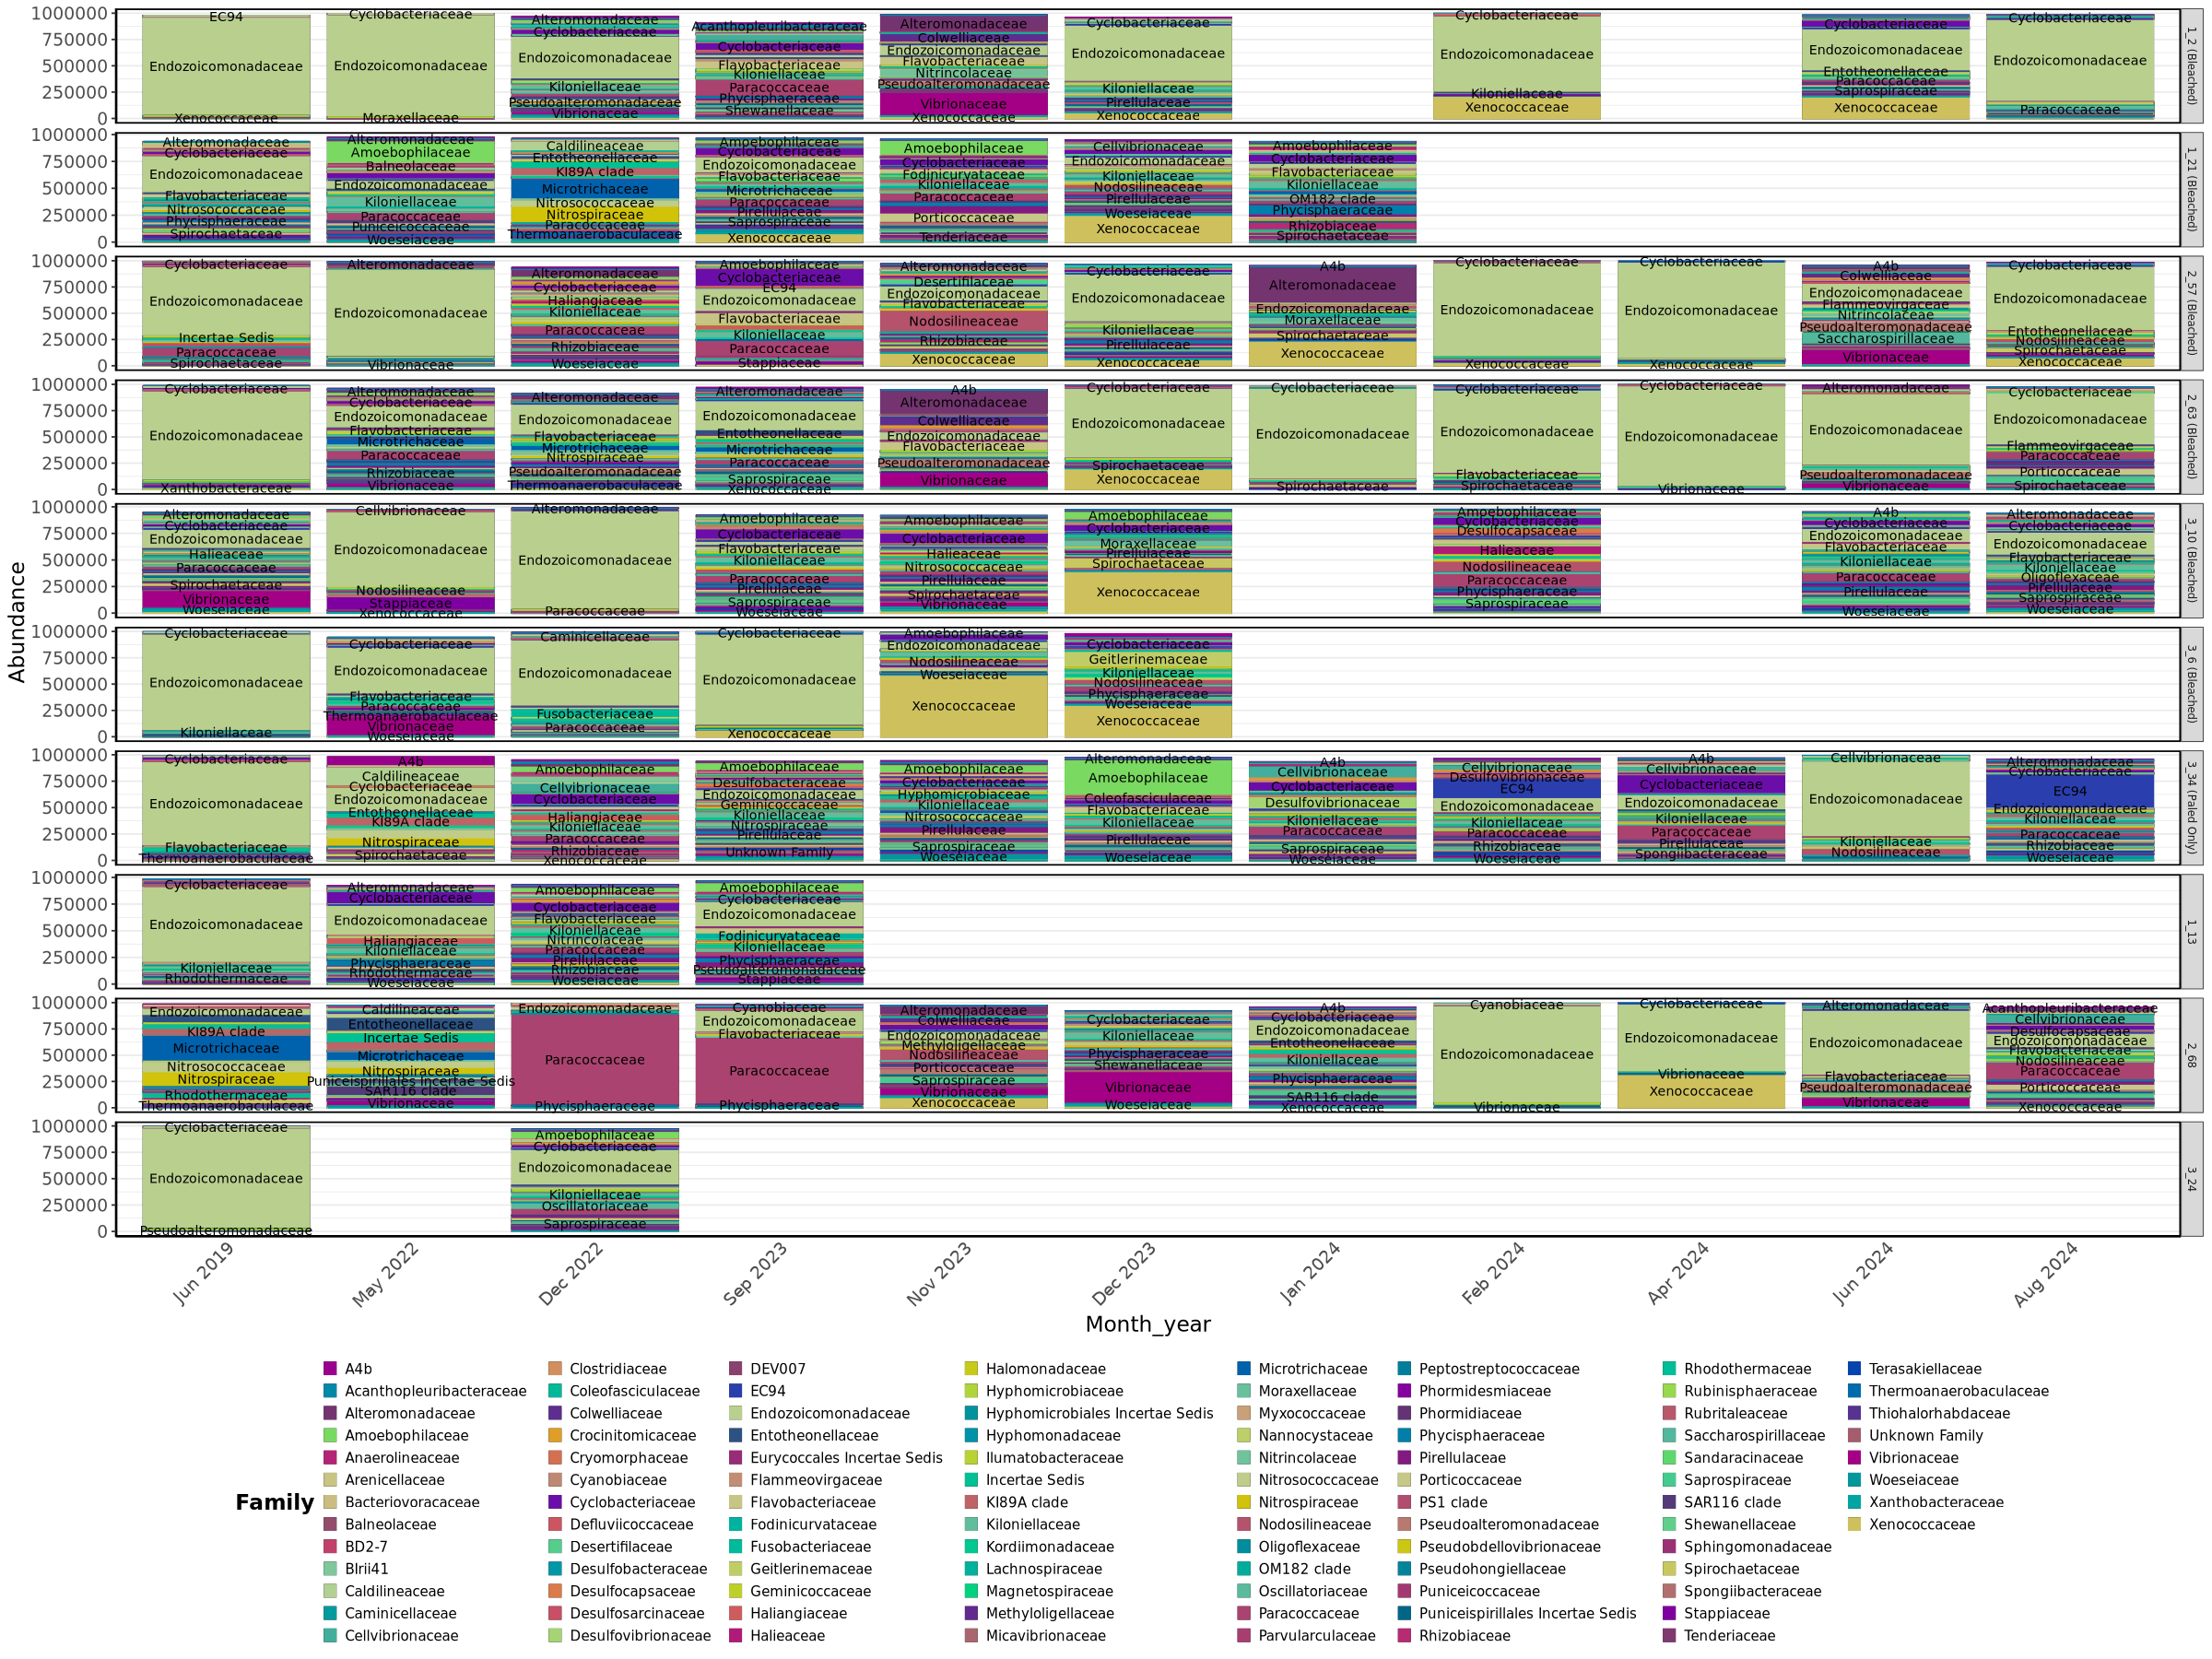

In [98]:

#plot
past_100 <- plot_bar(ps_fam100, x="Month_year", fill = "Family") +
  facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
   geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 3, check_overlap = TRUE) +
   scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    # Move legend to the bottom so the plot gets maximum width
    legend.position = "bottom",
    legend.box = "horizontal",
    
    # Scale down text & key sizes so it doesn't crowd out the plot vertically
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 9),
    legend.key.width = unit(0.3, "cm"),     
    legend.key.height = unit(0.3, "cm"),   
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 14), 
      strip.text = element_text(size = 7) # Alters only the facet font size
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 8, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 8)
  )
past_100

## top 25

In [99]:
top25 <- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:25] 
ps_fam25 <- prune_taxa(top25, ps_fam) 

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


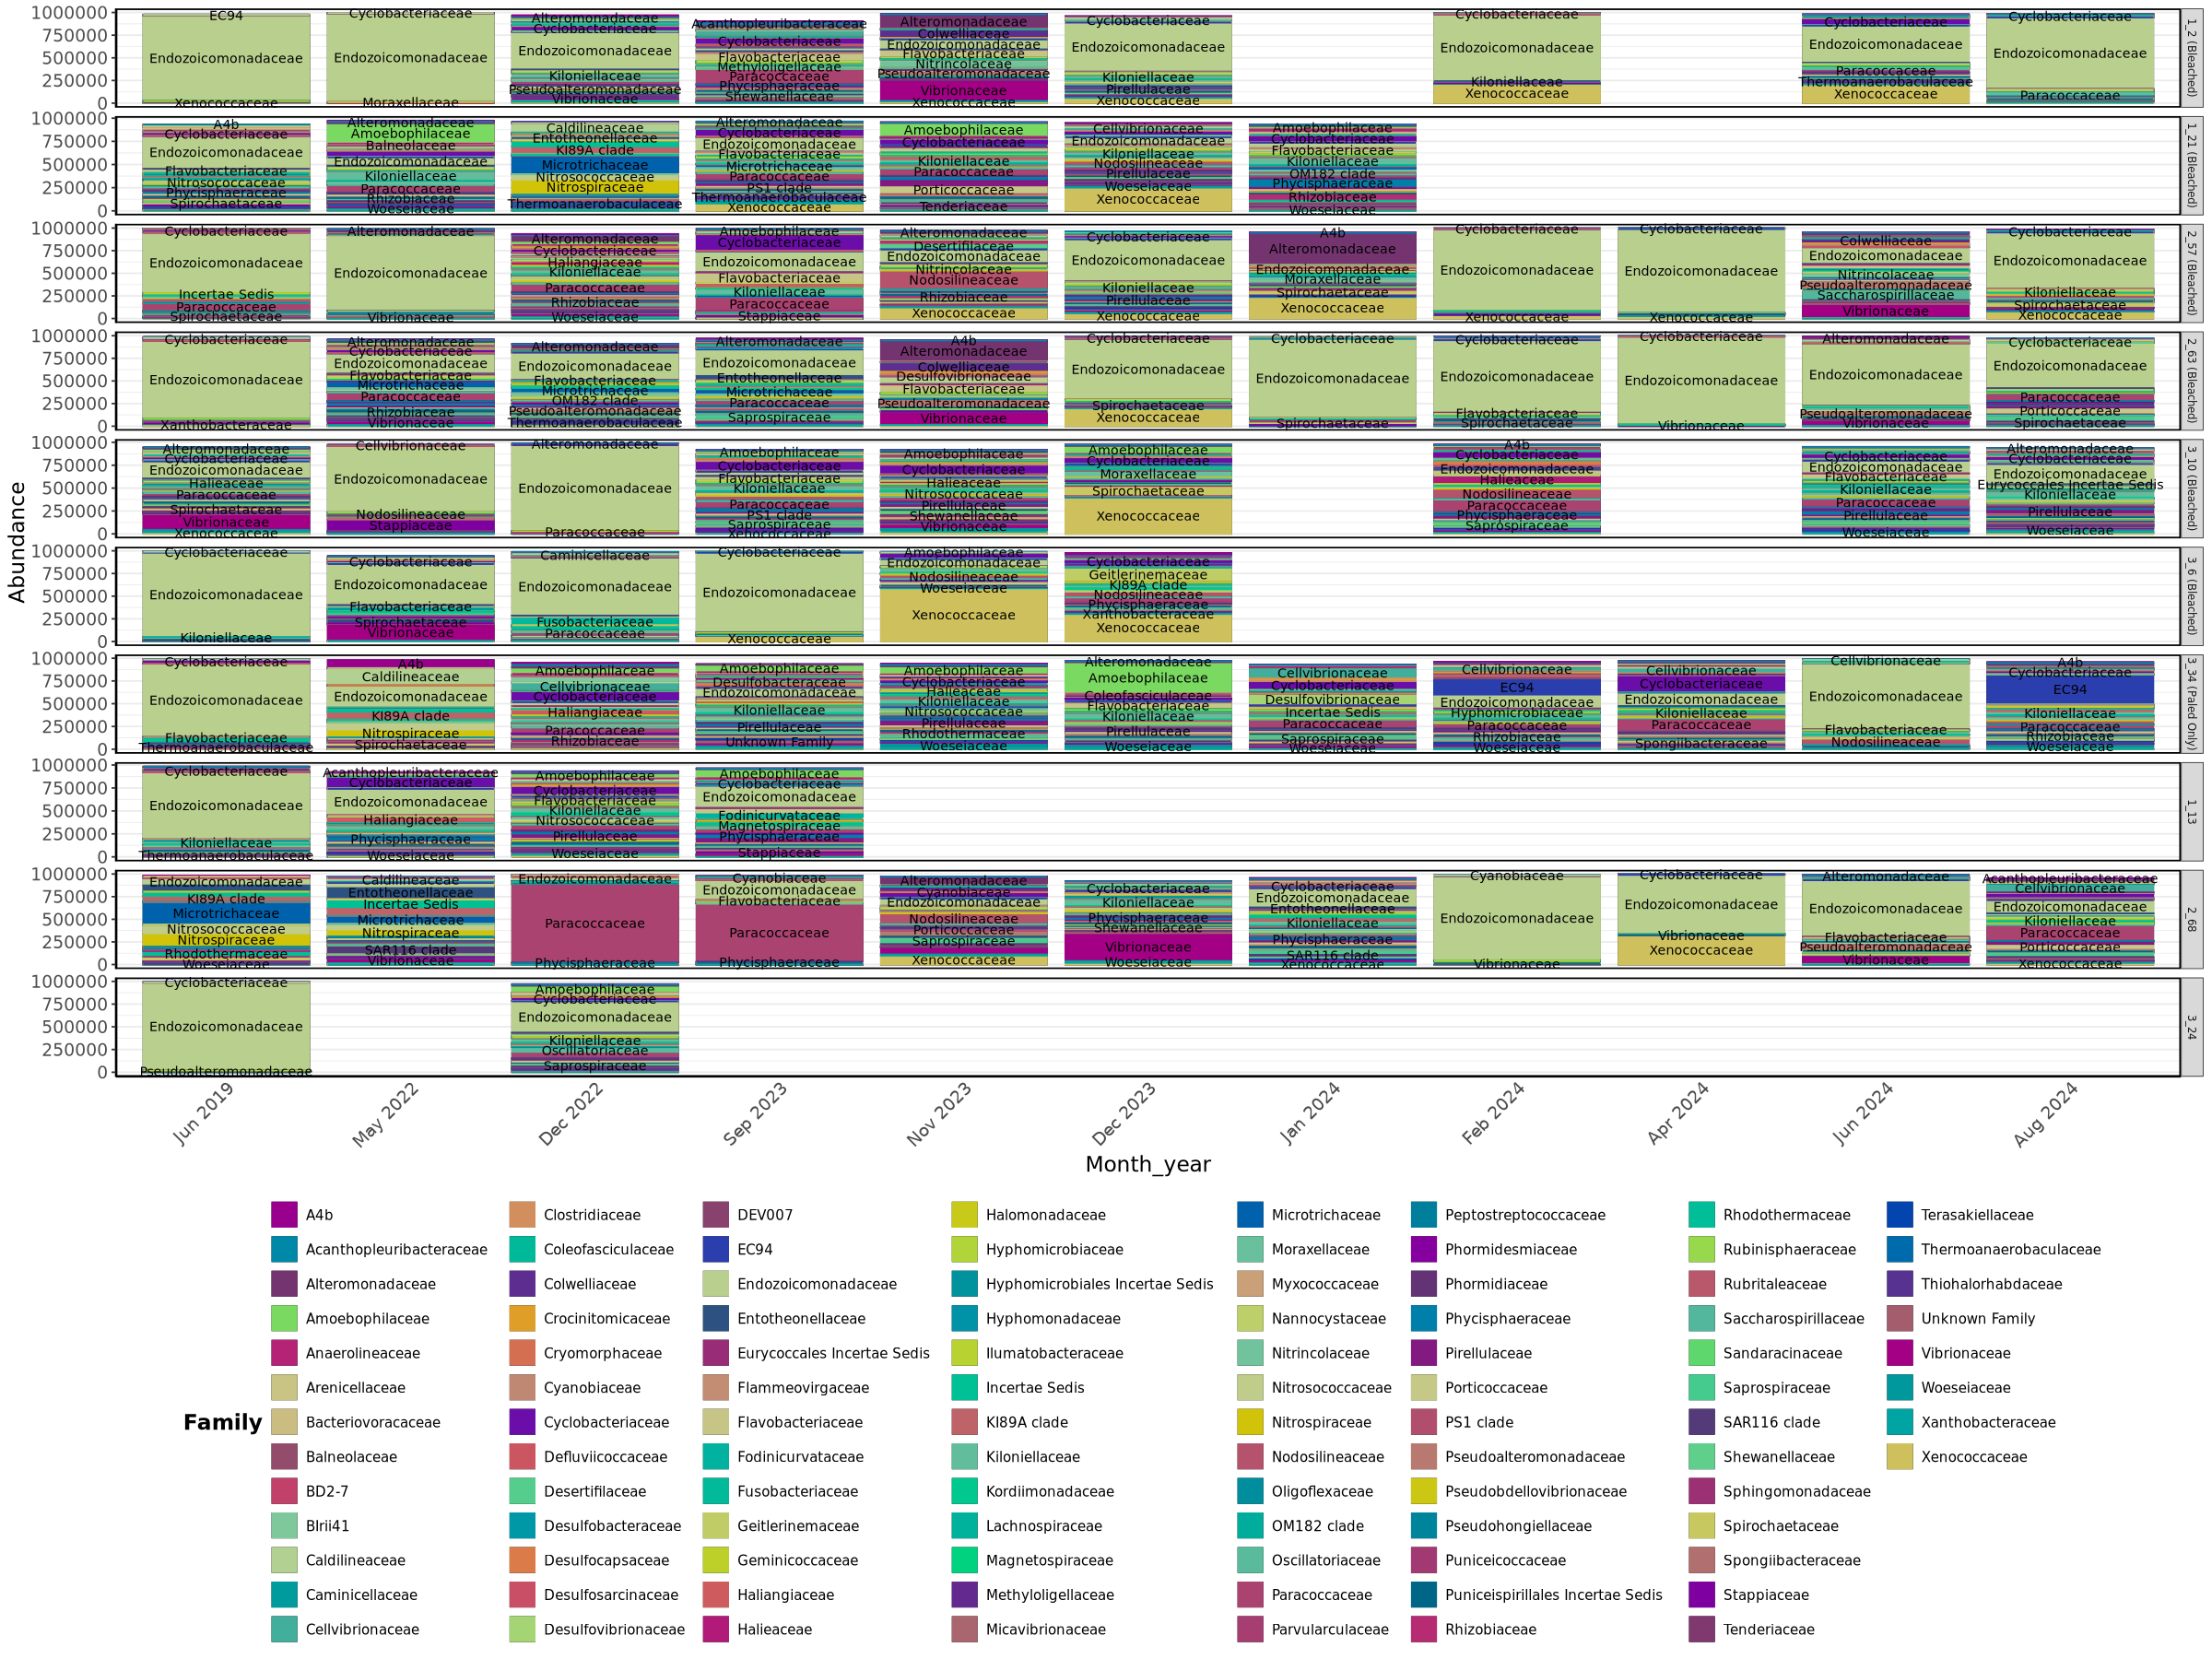

In [102]:
#plot
past_25 <- plot_bar(ps_fam100, x="Month_year", fill = "Family") +
  facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
   geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 3, check_overlap = TRUE) +
   scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    # Move legend to the bottom so the plot gets maximum width
    legend.position = "bottom",
    legend.box = "horizontal",
    
    # Scale down text & key sizes so it doesn't crowd out the plot vertically
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 9),
    legend.key.width = unit(0.6, "cm"),     
    legend.key.height = unit(0.6, "cm"),   
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 14), 
      strip.text = element_text(size = 7) # Alters only the facet font size
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 8, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 8)
  )
past_25

# look for endozoicomonas bleaching papers 

# DESEQ2
- DEseq2 is a popular differential expression analysis package available through Bioconductor. Its differential expression tests are based on a negative binomial generalized linear model. 

- use ps_col NOT ps_norm or ps_fam
- DESeq2 works with unnormalized data

## most basic model: 
test Health_status, bleached vs unbleached

In [60]:

bleachingdds = phyloseq_to_deseq2(ps_col, ~ Health_status)
bleachingdds = DESeq(bleachingdds, test="Wald", fitType="parametric")
res = results(bleachingdds, cooksCutoff = FALSE)
alpha = 0.05
sigtab = res[which(res$padj < alpha), ]
sigtab = cbind(as(sigtab, "data.frame"), as(tax_table(ps_col)[rownames(sigtab), ], "matrix"))
head(sigtab)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 14517 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Kingdom,Phylum,Class,Order,Family,Genus
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,2707.08749,-5.478953,1.2914782,-4.242389,2.211525e-05,1.136171e-03,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCACGTAGGCGGATCGGAAAGTTGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCTCCAAAACTATCGGTCTAGAGTTCGAGAGAGGTGAGTGGAATTCCGAGTGTAGAGGTGAAATTCGTAGATATTCGGAGGAACACCAGTGGCGAAGGCGGCTCACTGGCTCGATACTGACGCTGAGGTGCGAAAGTGTGGGG,14511.65688,-3.217460,0.9206667,-3.494707,4.745829e-04,1.685648e-02,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Paracoccaceae,Ruegeria
GCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGTCCGCAGGCGGCACTATAAGTCTGCTGTCAAAGACCGCAGCTCAACTGCGGAAAGGCAGTGGAAACTGTAGAGCTAGAGTACGGTAGGGGTAGAGGGAATTCCCAGTGTAGCGGTGAAATGCGTAGAGATTGGGAAGAACACCAGTGGCGAAAGCGCTCTACTGGGCCGTAACTGACGCTCAGGGACGAAAGCTAGGGG,4896.45488,-4.758832,1.0808304,-4.402940,1.067935e-05,5.689721e-04,Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Xenococcaceae,NA
GCAAGCGTTGTCCGGAATTATTGGGTTTAAAGGGTGTGTAGGCGGCTAATTAAGTCAGAGGTGAAATGCTAGAGCTTAACTTTAGAACGGCCTTTGAAACTAGTTAGCTTGAGTCAAGGAGAGGTAGGGAGAATTTATGGTGGAGCGGTGAAATGCATAGATACCATAAGGAATACCGATAGCGAAGGCCCCTTACTGGCCTTTGACTGACGCTGAGACACGAAAGCGTGGGT,4304.50391,-6.223867,1.0473431,-5.942529,2.806579e-09,1.583241e-07,Bacteria,Bacteroidota,Bacteroidia,Cytophagales,Amoebophilaceae,NA
GCAAGCGTTAATCGGAATCACTGGGCGTAAAGCGTACGTAGGCGGCGCGGCAAGTCAGAAGTGAAAGCCCTCGGCTCAACCGAGGAATTGCTTTTGAAACTGCCGTGCTTGAGTCTCGGAGAGGTTGGCGGAATTCCAGGTGTAGGAGTGAAATCCGTAGATATCTGGAGGAACACCAGTGGCGAAGGCGGCCAACTGGACGAGTACTGACGCTGAGGTACGAAAGCGTGGGG,34.18483,25.483774,3.5039214,7.272930,3.517731e-13,3.804443e-11,Bacteria,Thermodesulfobacteriota,Desulfovibrionia,Desulfovibrionales,Desulfovibrionaceae,Pseudodesulfovibrio
GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGCGCGTAGGCGGGGTATCAAGTTAGGGGTGAAAGCCCGGGGCTCAACCTCGGAACTGCCTTTAAAACTGATACTCTAGAGTCCGGAAGAGGGTCGCGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCGGTGGCGAAGGCGGCGACCTGGTCCGGTACTGACGCTGAGGCGCGAAAGCGTGGGG,1054.35813,-5.151981,1.3316096,-3.868987,1.092883e-04,4.990832e-03,Bacteria,Pseudomonadota,Alphaproteobacteria,Kiloniellales,Kiloniellaceae,Thalassocola


When using this function we need to tell DESeq2 what comparison to make. This is only necessary if the design formula is multi-factorial or, as in our case, the variable in the design formula has more than 2 levels. This is done with the contrast parameter which takes a character vector of three elements giving the name of the factor of interest, the numerator (i.e. comparator), and the denominator (i.e. control).

In [61]:
# Search your unfiltered significant table for the family
sigtab[grep("Endozoicomonadaceae", sigtab$Family), ]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Kingdom,Phylum,Class,Order,Family,Genus
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACTTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,11.827116,24.022580,2.376529,10.108265,5.077550e-24,1.460811e-20,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCATGTAAGTTGGATGTGAAAGCCCCGGGCTCAACCTGGGAACTGCATCCAAAACTGGGTGGCTAGAGTACGGGAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAGGAACACCAGTGGCGAAGGCGACACTCTGGCCTGATACTGACGCTGAGGTACGAAAGCGTGGGG,4512.920658,-8.119047,1.826543,-4.445034,8.787790e-06,4.770278e-04,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Endozoicomonas
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTGATAAGTTGGATGTGAAAGCCCTGGGCTCAACCTGGGAACTGCATCCAAAACTGTCAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAGGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,55.731523,26.173496,3.503766,7.470103,8.013214e-14,1.097810e-11,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Sansalvadorimonas
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTGTTAAGTTGGATGTGAAAGCCCTGGGCTCAACCTGGGAACTGCATCCAAAACTGGCAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAGGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,25.506608,25.080154,3.504037,7.157502,8.216048e-13,7.625022e-11,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Sansalvadorimonas
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCTCGCTAAGTTGGATGTGAAAGCCCCGGGCTCAACCTGGGAACTGCATCCAAAACTGGCGAGCTAGAGTGCGGAAGAGGGGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAGGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,22.247432,24.452511,3.504105,6.978248,2.988838e-12,2.204843e-10,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Endozoicomonas
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCATTTAAGTTGGATGTGAAAGCCCCGGGCTCAACCTGGGAACTGCATCCAAAACTGGGTGGCTAGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAGGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,9.227418,23.652225,3.504726,6.748667,1.492099e-11,8.943269e-10,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Endozoicomonas


In [62]:
dim(sigtab)

[1] 133  12

In [63]:

bleaching_taxa=sigtab[,c("log2FoldChange", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus")] 
bleaching_taxa <- as.matrix(bleaching_taxa)

In [64]:
##turn into phyloseq object
sigbleachingTAX <- tax_table(bleaching_taxa)
ps_bleaching_log <- ps_col
tax_table(ps_bleaching_log)=sigbleachingTAX
     

In [85]:

##filter for asvs found in 40% of samples
ps_bleaching_log_filter <- genefilter_sample(ps_bleaching_log, filterfun_sample(function(x) x > 1), A=0.15*nsamples(ps_bleaching_log))
ps_bleaching_log_prune <- prune_taxa(ps_bleaching_log_filter, ps_bleaching_log)
     

bleaching_log_prune=ps_bleaching_log_prune
tax_table(bleaching_log_prune) <- tax_table(bleaching_log_prune)[,2:7]
taxmap_bleaching <- parse_phyloseq(bleaching_log_prune)

The following 20 of 61 (32.8%) input indexes have `NA` in their classifications:
   3, 4, 12, 13, 15, 22, 24, 29 ... 44, 46, 51, 54, 56, 57, 58, 59




## what are the significant asvs between bleached and non-bleached PASTs?

In [86]:
# 1. Get the list of ASV IDs that survived the 40% prevalence filter
final_asvs <- taxa_names(bleaching_log_prune)

In [87]:
# 2. Pull just 90% ASVs out of your original sigtab to get their log2FoldChange and taxonomy
plot_data <- as.data.frame(sigtab[final_asvs, c("log2FoldChange", "Phylum", "Family")])
plot_data$ASV_ID <- rownames(plot_data)

# 3. Add your preferred "Rank_" prefixes 
plot_data$Genus <- paste0("Family_", plot_data$Family)
plot_data$Phylum <- paste0("Phylum_", plot_data$Phylum)

# 4. Clean up: Ensure log2FoldChange is numeric and remove unclassified Genera ("Genus_NA")
plot_data$log2FoldChange <- as.numeric(plot_data$log2FoldChange)
plot_data <- plot_data[!grepl("_NA$", plot_data$Family), ]

In [88]:
# 5. Crucial Step: Arrange by log2FoldChange and force R to keep duplicate 
# Genus names as separate rows on the plot by making it an ordered factor
plot_data <- plot_data[order(plot_data$log2FoldChange), ]
plot_data$Family_Unique <- factor(seq_len(nrow(plot_data)), labels = plot_data$Family)


### threshold over 15%
- Endozoic is negative and positive at the same time. that indicates that it is enriched in both Bleached_Tissue and Healthy
- what Am I doing wrong??

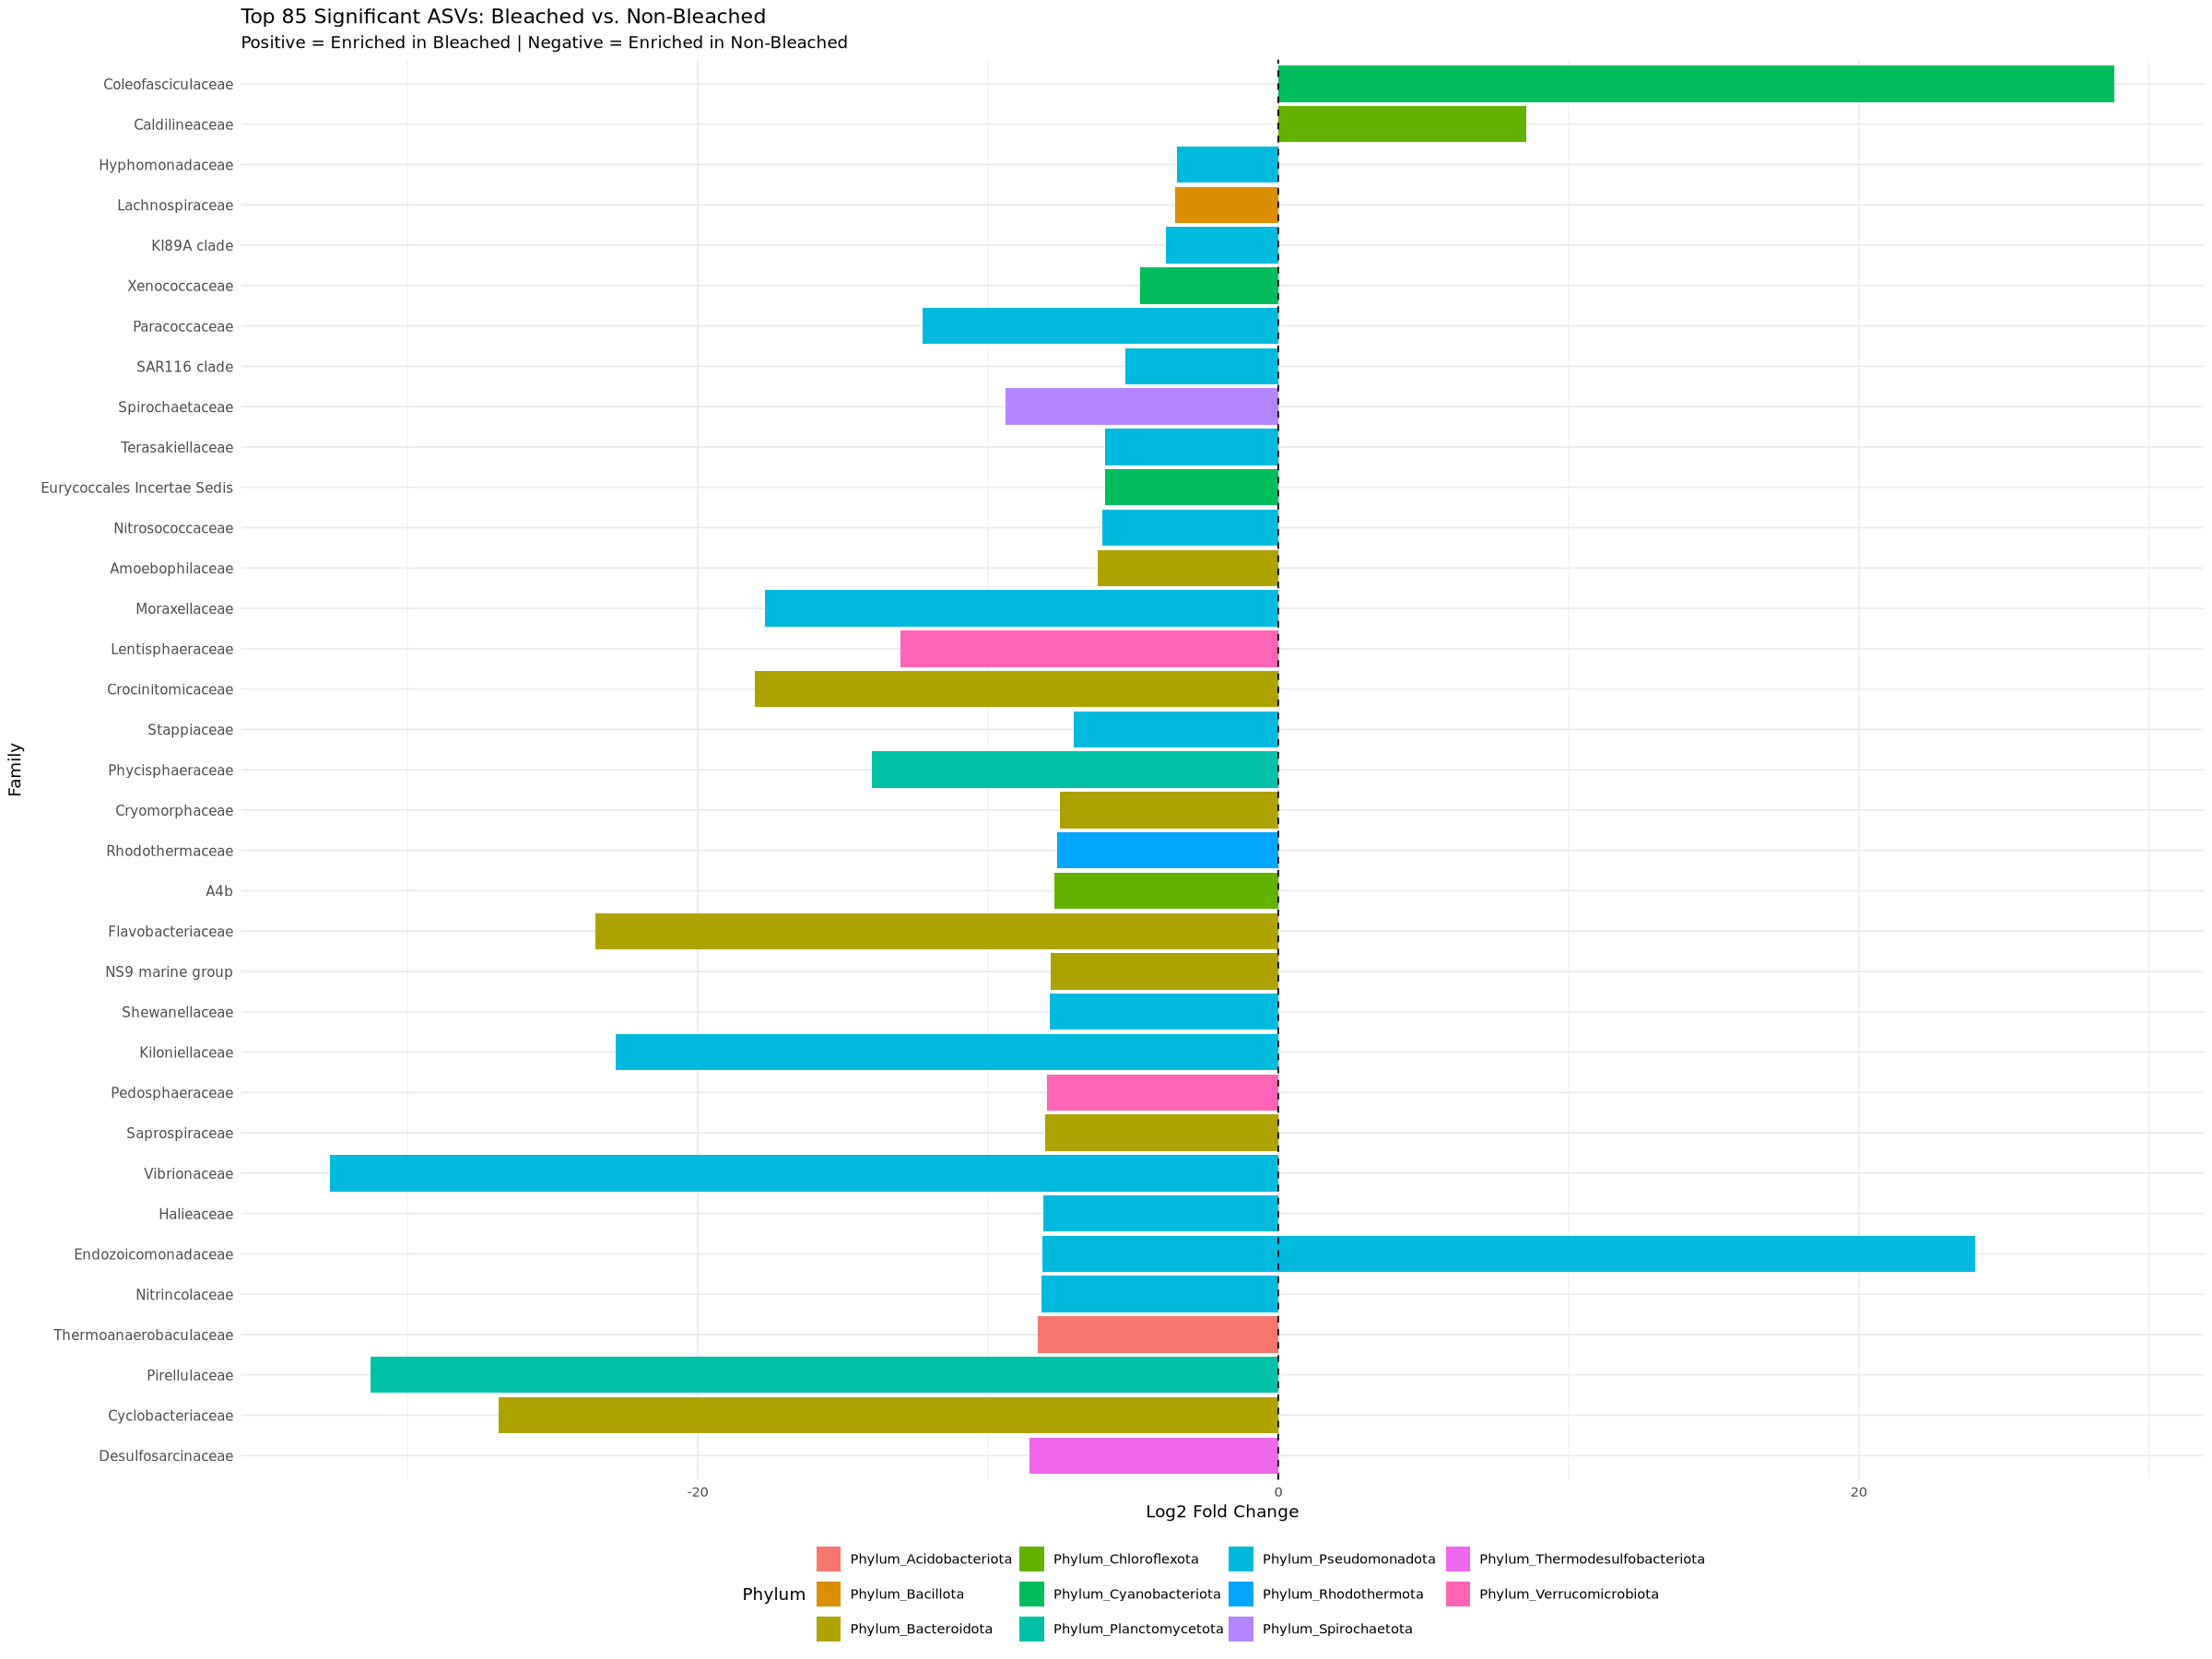

In [90]:
# 6. Generate the Clean Bar Plot
ggplot(plot_data, aes(x = log2FoldChange, y = Family_Unique, fill = Phylum)) +
  geom_bar(stat = "identity") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
  labs(
    title = "Top 85 Significant ASVs: Bleached vs. Non-Bleached",
    subtitle = "Positive = Enriched in Bleached | Negative = Enriched in Non-Bleached",
    x = "Log2 Fold Change",
    y = "Family",
    fill = "Phylum"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 9),
    legend.position = "bottom"
  )

### threshold of over 20%

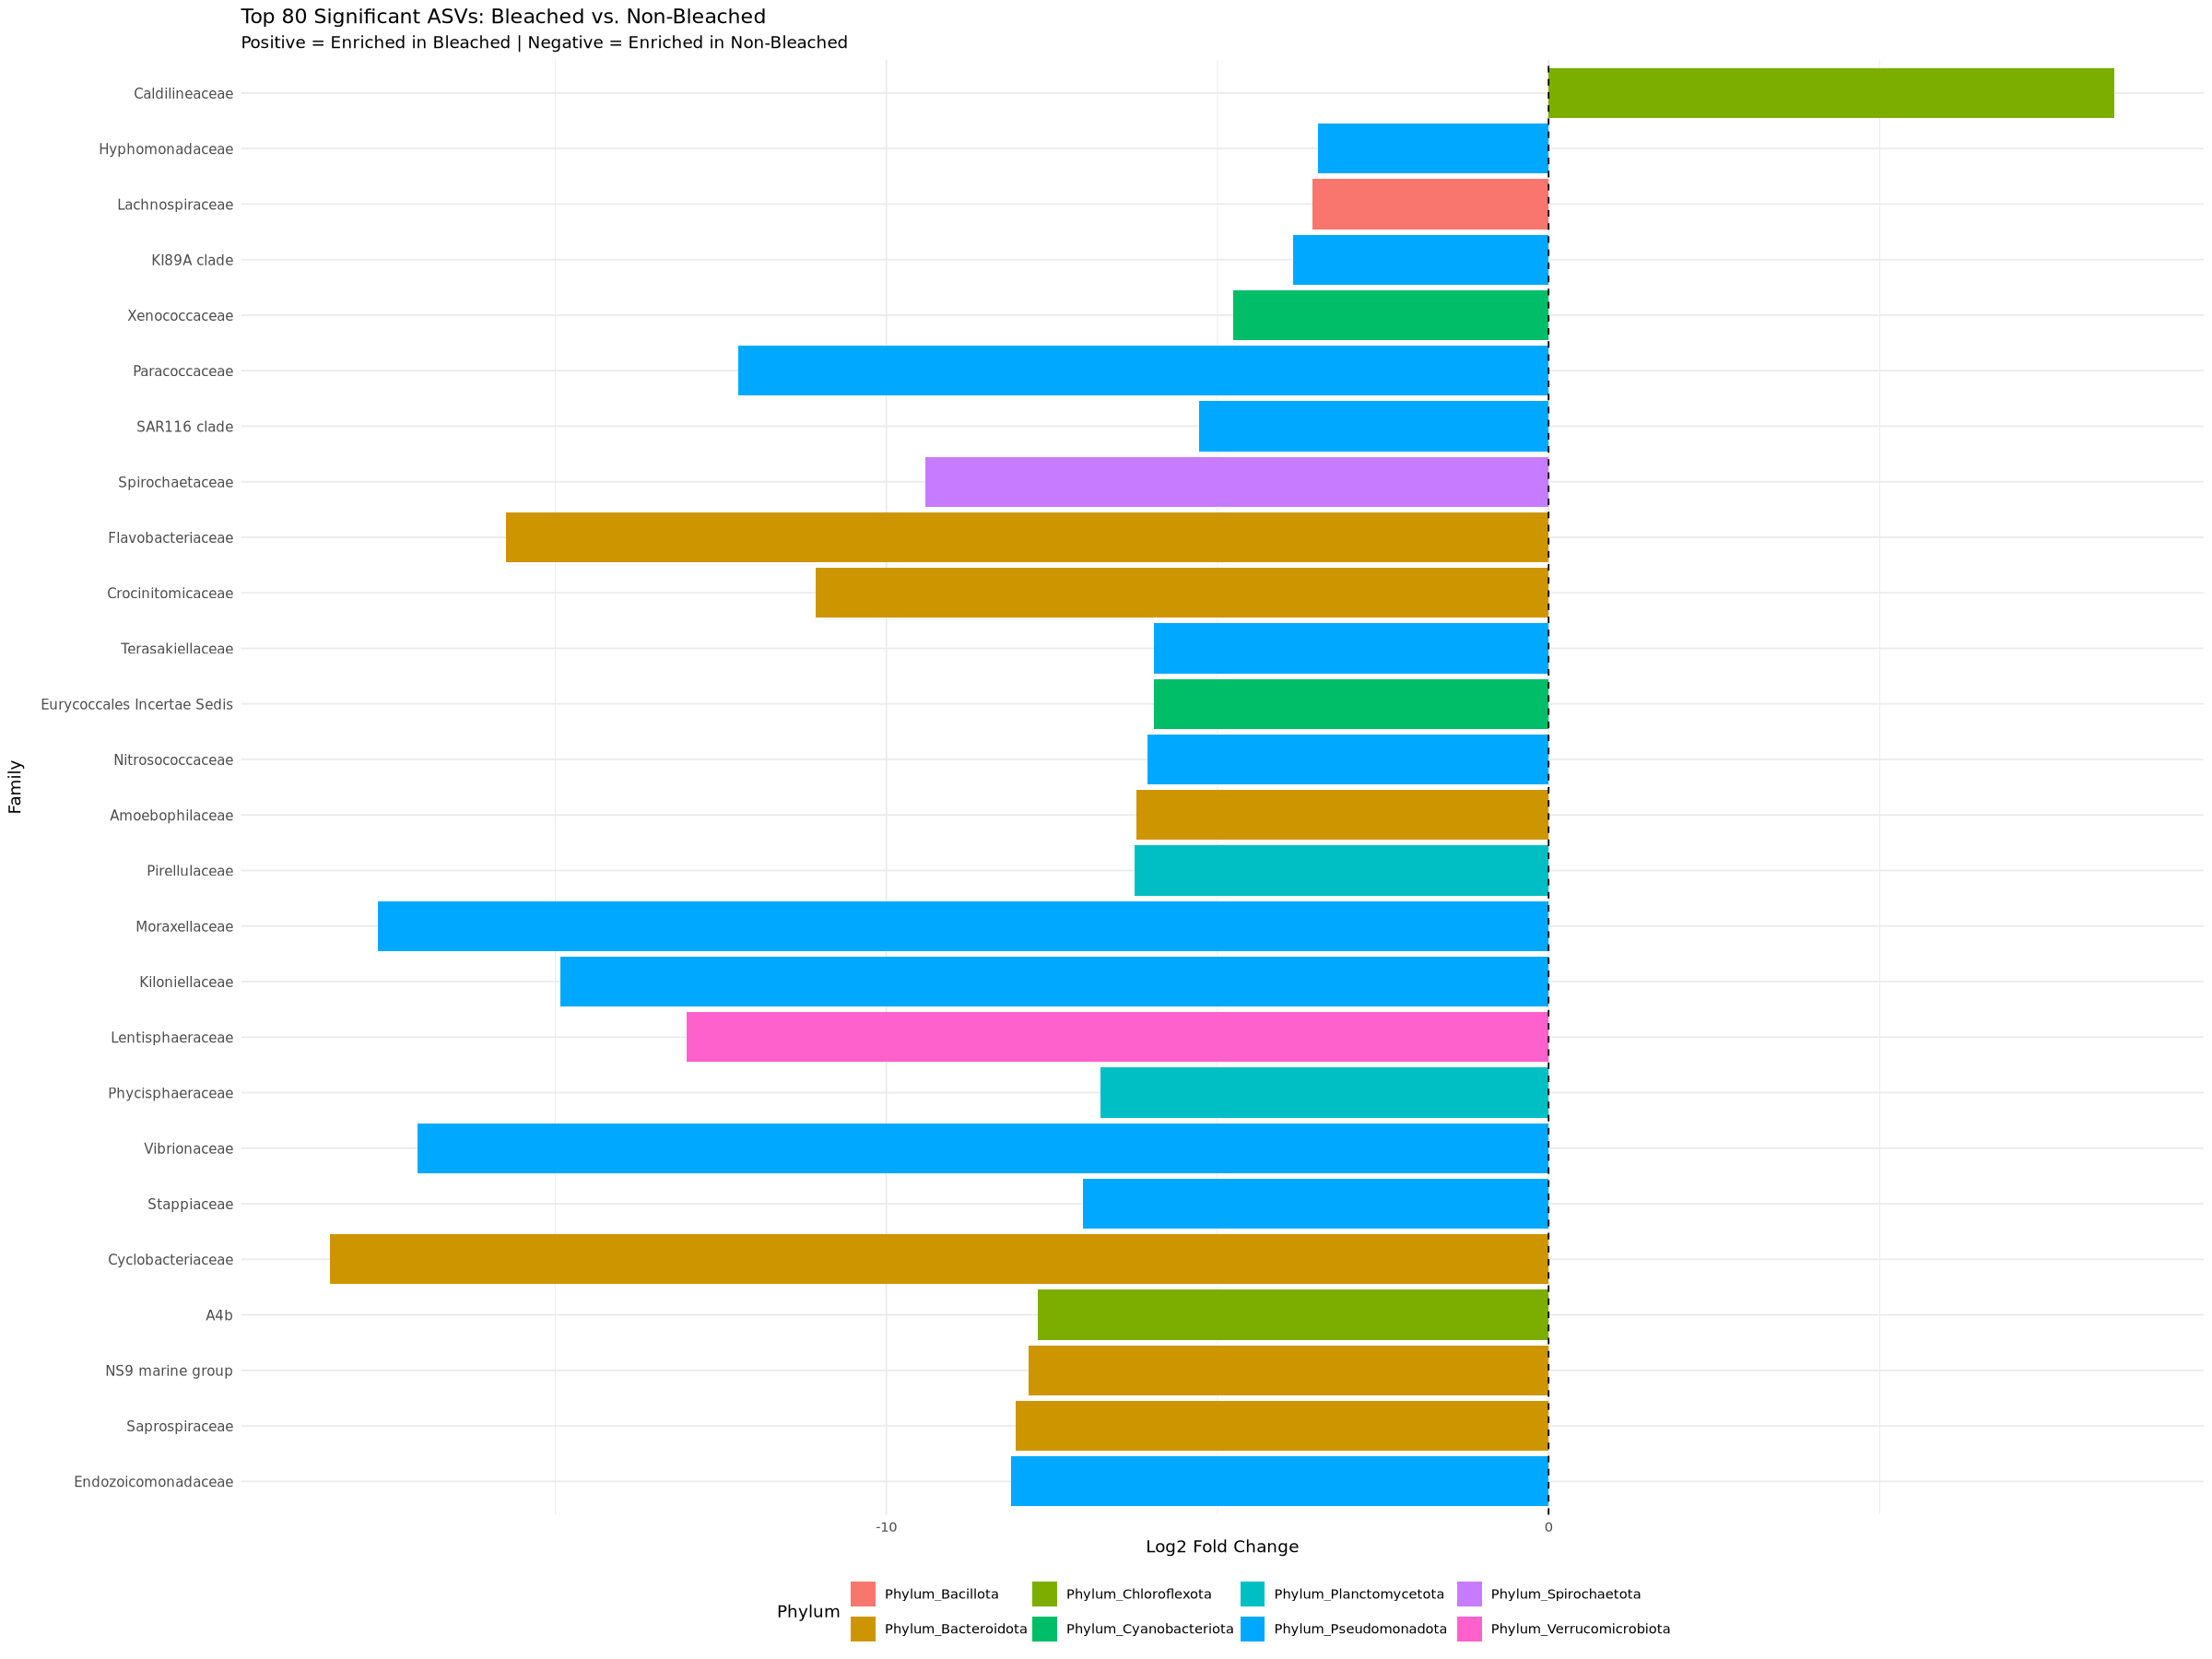

In [84]:
# 6. Generate the Clean Bar Plot
ggplot(plot_data, aes(x = log2FoldChange, y = Family_Unique, fill = Phylum)) +
  geom_bar(stat = "identity") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
  labs(
    title = "Top 80 Significant ASVs: Bleached vs. Non-Bleached",
    subtitle = "Positive = Enriched in Bleached | Negative = Enriched in Non-Bleached",
    x = "Log2 Fold Change",
    y = "Family",
    fill = "Phylum"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 9),
    legend.position = "bottom"
  )

## another more complicated option  
**is testing how microbial abundance changes based on Health_status, and individual colony**
- no intervariable interactions yet;
    - but I may be interested in seeing how colony (or species in a larger sense) interact with  Month_year or DHW
    - interactions test "does the effect of month_year on the microbiome depend on which colony is looked at?"
    ``` 
   (ps_col, ~ Month_year * colony + Health_status
    ```
    - Month_year.colony...: The interaction term. If this is statistically significant for a specific microbe, it means the relationship between Month_year and that microbe changes depending on the colony.
    - the above model would be controlling for baseline health_status
    - **may want to change the model to control for colony**

### could also create new column in ps_col to reflect resistant/suseptible to bleahcing


```
bleachingdds = phyloseq_to_deseq2(ps_col, ~ Health_status + colony)
```
If Endozoicomonadaceae drops significantly during bleaching, but its starting abundance varies wildly from Colony A to Colony B to Colony C, DESeq2 attributes that variation to the colony variable rather than the Health_status variable.

- want to capture colonies resistant/suseptible to bleaching

- here I basically nested colony_labeled+Condition into its own column ($Group), and am running a model on that

### when I was testing Health_status + colony

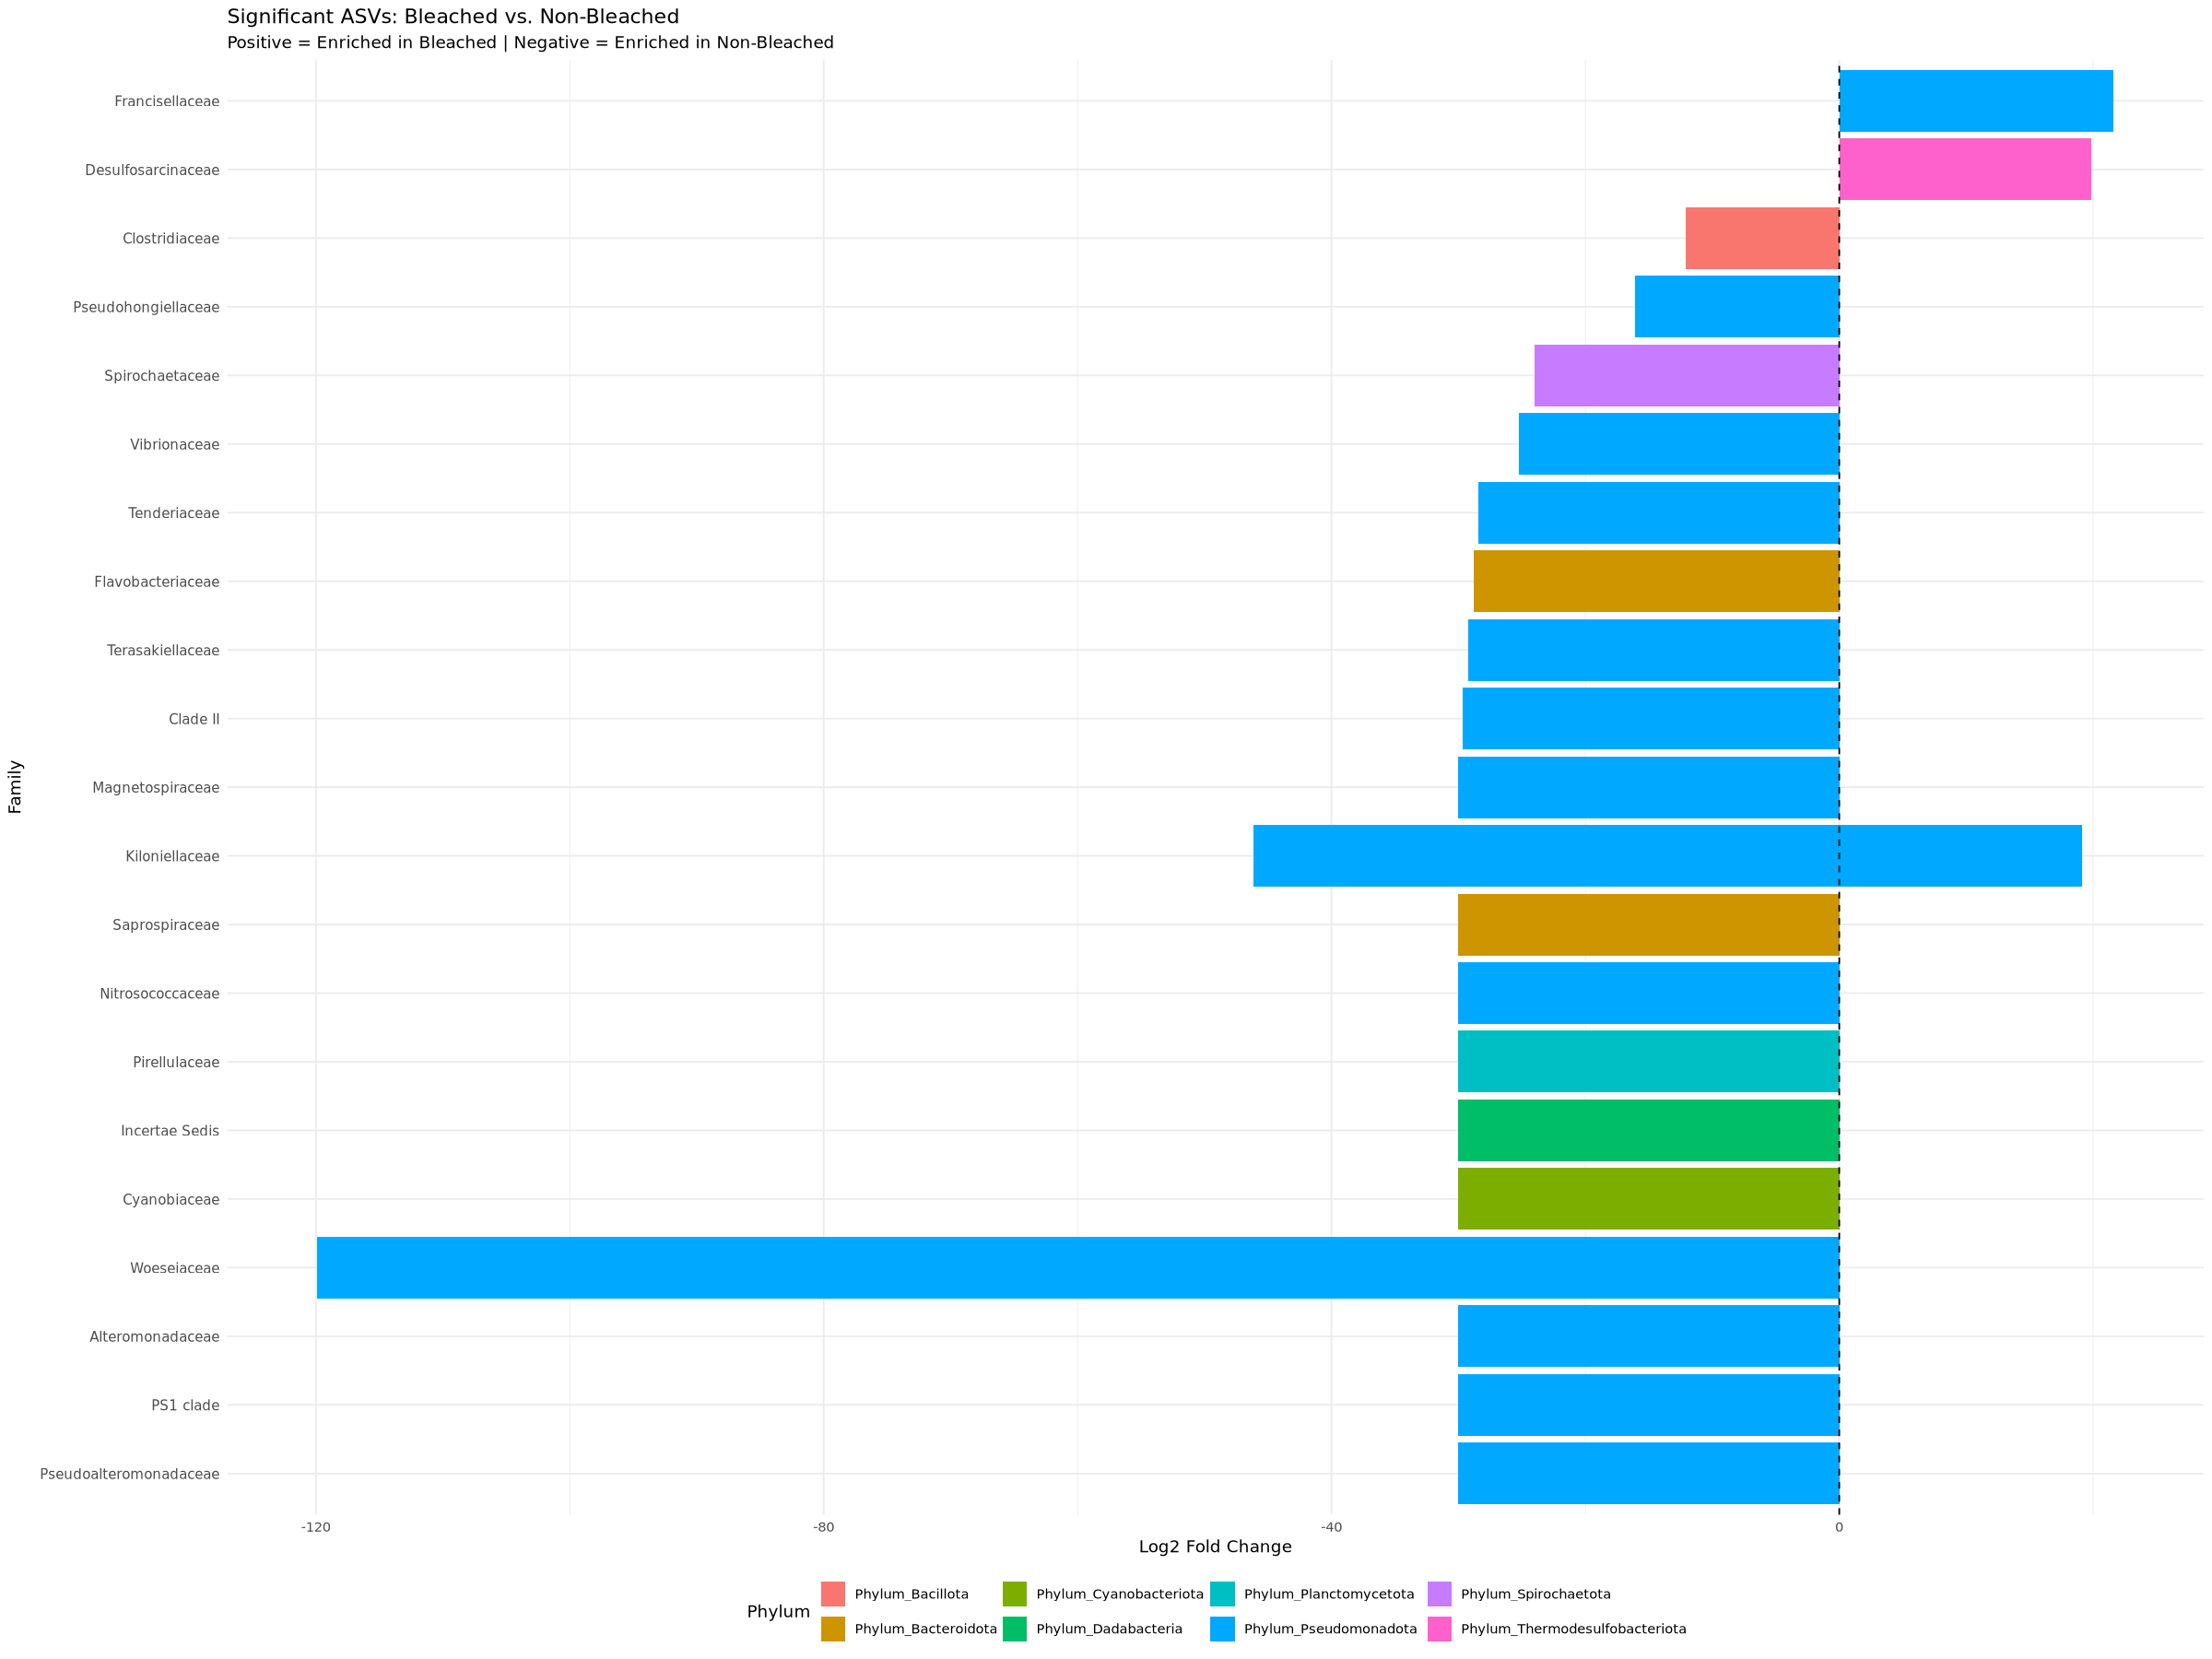

In [51]:
# 6. Generate the Clean Bar Plot
ggplot(plot_data, aes(x = log2FoldChange, y = Family_Unique, fill = Phylum)) +
  geom_bar(stat = "identity") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
  labs(
    title = "Significant ASVs: Bleached vs. Non-Bleached",
    subtitle = "Positive = Enriched in Bleached | Negative = Enriched in Non-Bleached",
    x = "Log2 Fold Change",
    y = "Family",
    fill = "Phylum"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 9),
    legend.position = "bottom"
  )

## making a tree for microbe composition of PAST samples

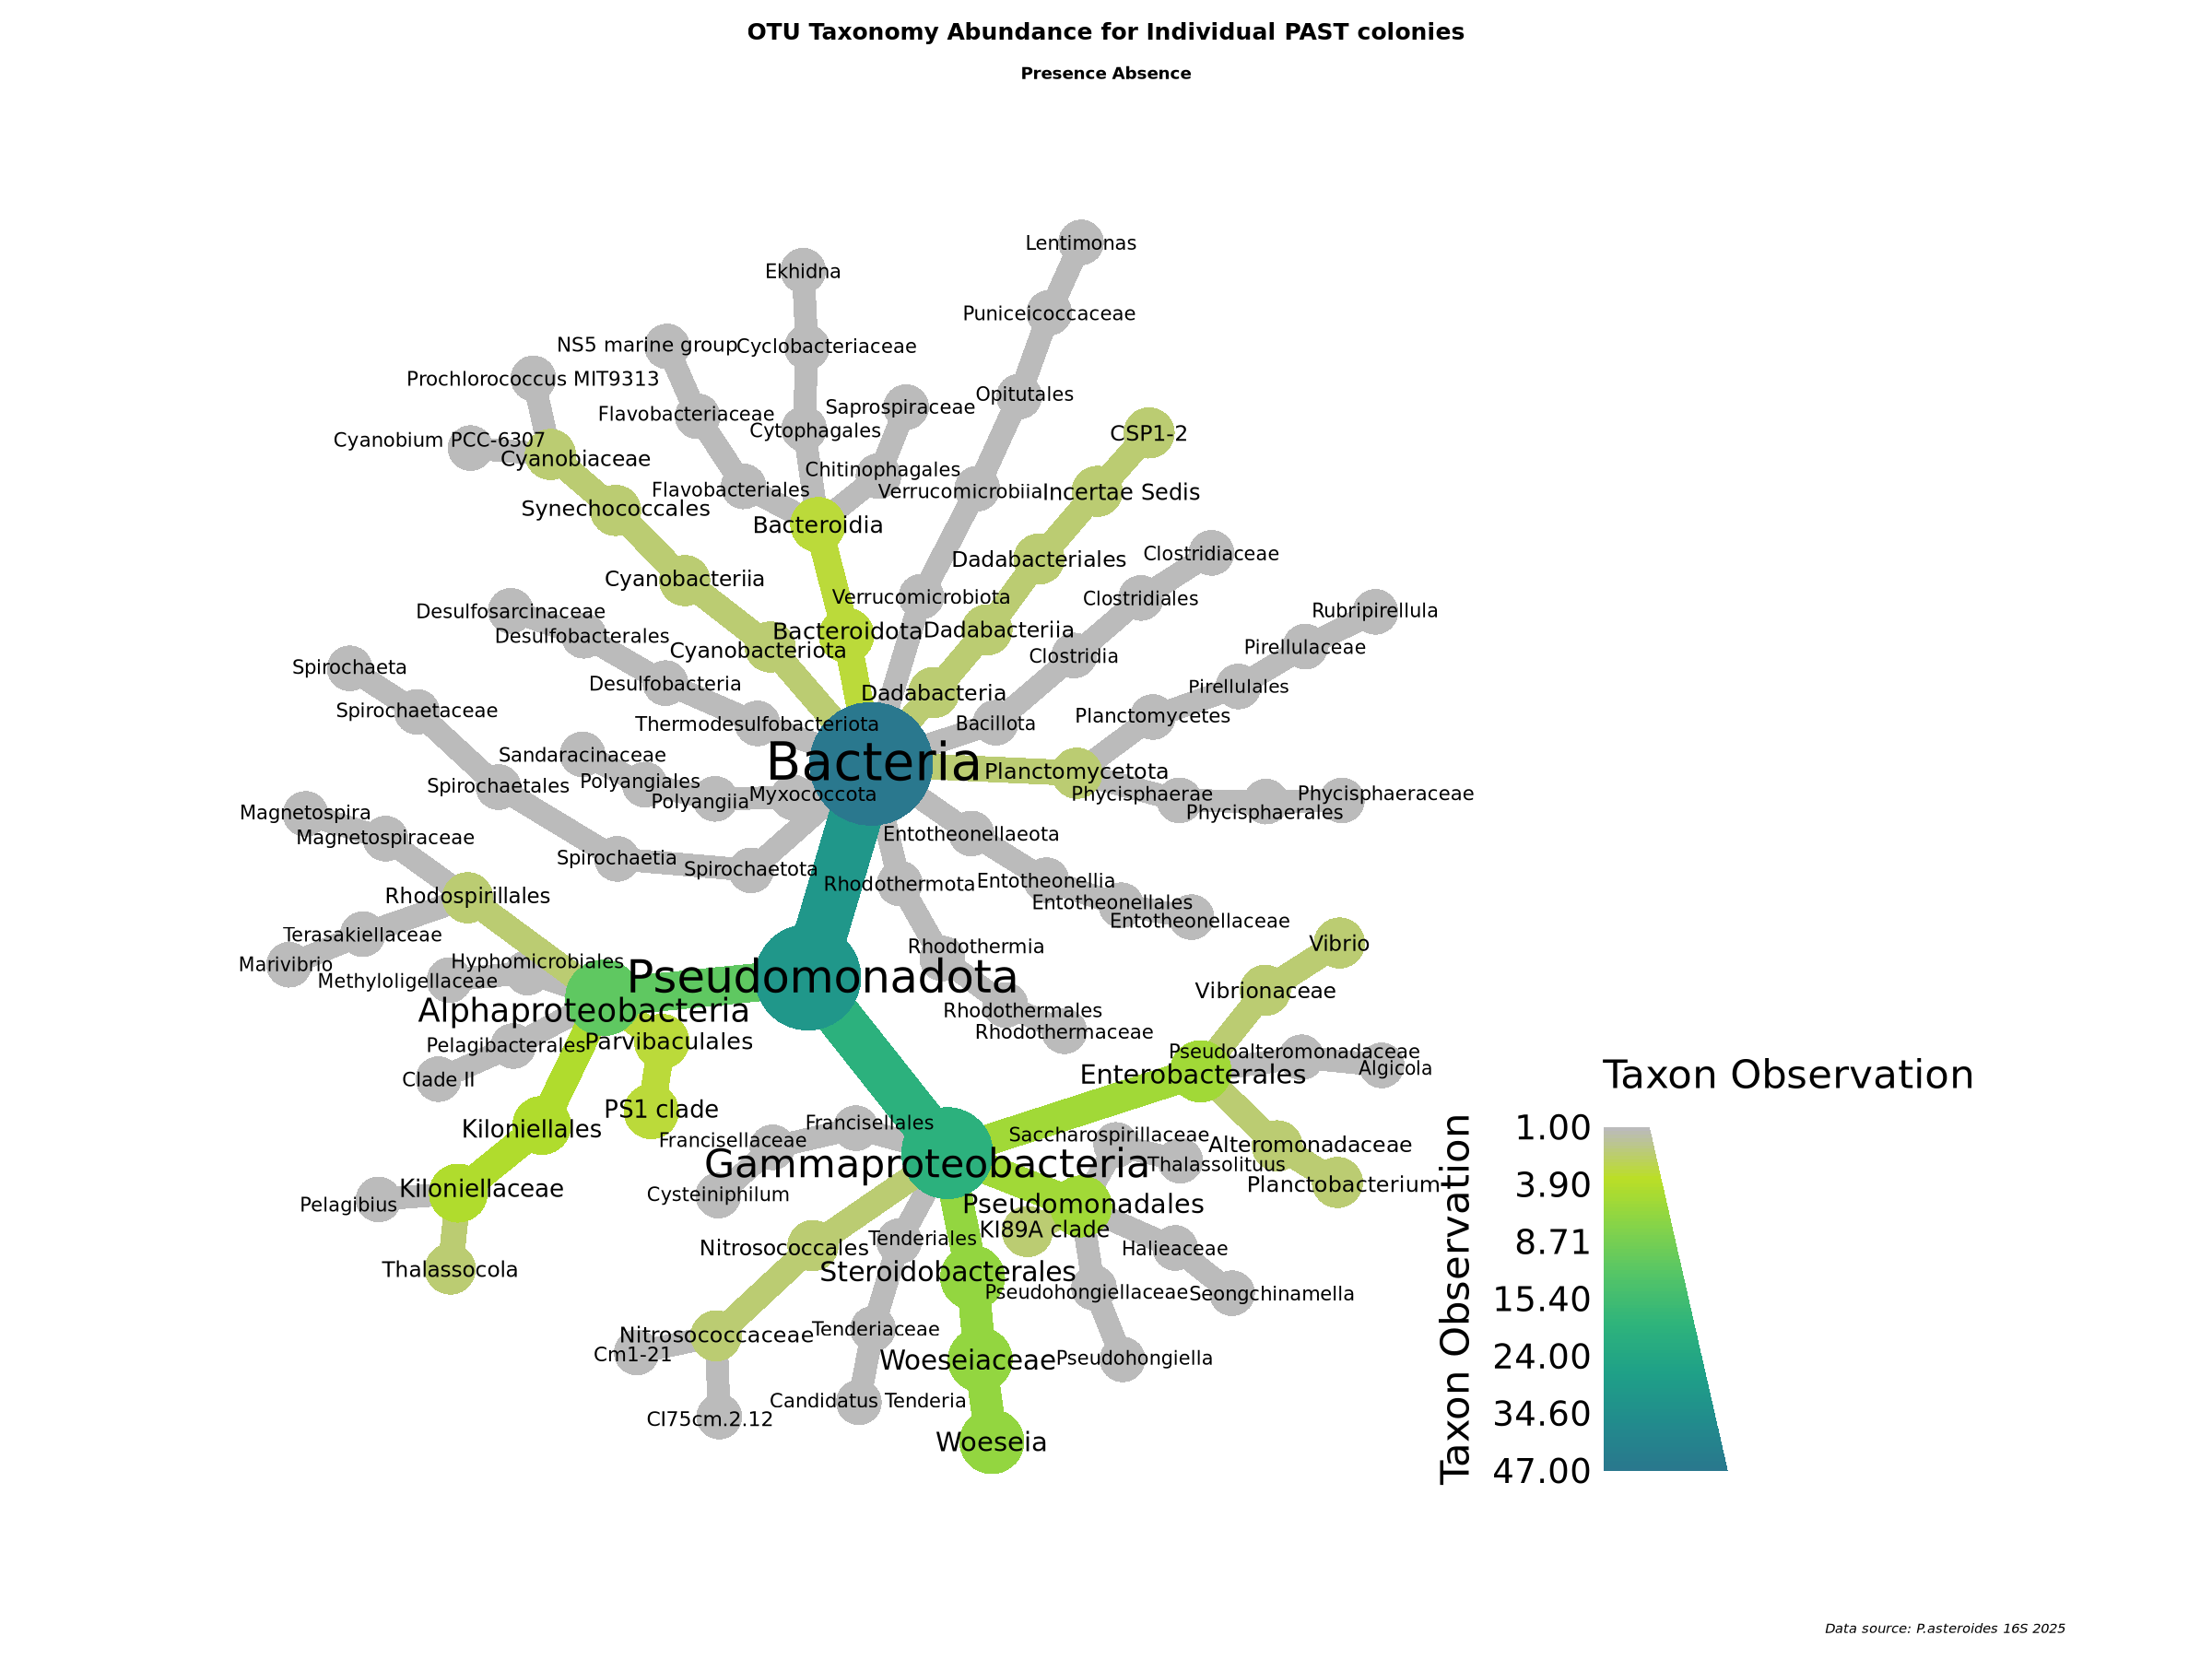

In [35]:

taxmap_bleaching %>% 
  heat_tree(node_label = taxon_names,
            node_size = n_obs(taxmap_bleaching),
            node_color = n_obs(taxmap_bleaching),
            layout = "davidson-harel", initial_layout = "reingold-tilford", 
            node_legend_title	= "Taxon Observation", 
            node_color_axis_label ="Taxon Observation",
            margin_size = c(0.1, 0.1, 0.1, 0.1))+
  theme(legend.position = "none", 
        legend.text=element_text(size=8),
        axis.text.x = element_blank(),
        plot.title = element_text(face = "bold", hjust = 0.5, size = 15, colour = "black", margin=margin(15, 15, 0, 15)), 
        plot.subtitle = element_text(face = "bold", hjust = 0.5, color = "black", margin=margin(15, 15, 15, 15), ),
        plot.caption = element_text(color = "black", face = "italic", margin=margin(15, 15, 15, 15)),
        axis.title.x = element_blank(), 
        axis.title.y = element_blank())+
  labs(title = "OTU Taxonomy Abundance for Individual PAST colonies", 
       subtitle = "Presence Absence",
       caption = "Data source: P.asteroides 16S 2025")

## figure notes
- don't see endozzoicomonas here because it is every colony?

look at the OTUs that were significantly different between the two health_status. The following makes a nice ggplot2 summary of the results.

In [36]:
bleachLog=as.data.frame(tax_table(bleaching_log_prune))
for (i in colnames(bleachLog)[2:NCOL(bleachLog)]){
  bleachLog[[i]] <- (str_c(i, "_", bleachLog[[i]]))}
bleachLog=as.data.frame(t(bleachLog))
bleachLog=as.data.frame(t(fill(bleachLog, names(bleachLog))))
bleachLog$OTU = row.names(bleachLog)bleachLog$log2FoldChange=as.numeric(bleachLog$log2FoldChange)
     

ERROR: Error in parse(text = x, srcfile = src): <text>:6:37: unexpected symbol
5: bleachLog=as.data.frame(t(fill(bleachLog, names(bleachLog))))
6: bleachLog$OTU = row.names(bleachLog)bleachLog
                                       ^


In [ ]:
head(bleachLog)

In [ ]:

mycolors= colorRampPalette(brewer.pal(8, "Set1"))(9)

ggplot(bleachLog,aes(x = OTU, y=log2FoldChange, fill = Genus)) +
  geom_bar(stat="identity")+
  #scale_fill_brewer(palette="Dark2")+
  geom_text(aes(label=log2FoldChange), vjust=1.6, color="black",
            position = position_dodge(0.9), size=8)+
scale_fill_manual(values = mycolors)+
  scale_y_continuous(limits = c(-5, 5))+
  geom_hline(yintercept = 0)+
theme_bw()+
   theme(legend.position="right",
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        legend.text=element_text(size=20),
        axis.line = element_line(color="black"), text = element_text(size=20), 
        axis.title.x = element_text(face = "bold", size = 25, margin=margin(15, 15, 15, 15)),
        axis.title.y = element_text(face = "bold", size = 25, margin=margin(15, 15, 15, 15)), 
        panel.border = element_rect(color = "black",fill = NA,size = 1))+
  labs(x = "OTU",
       y = "Log2Fold Change")

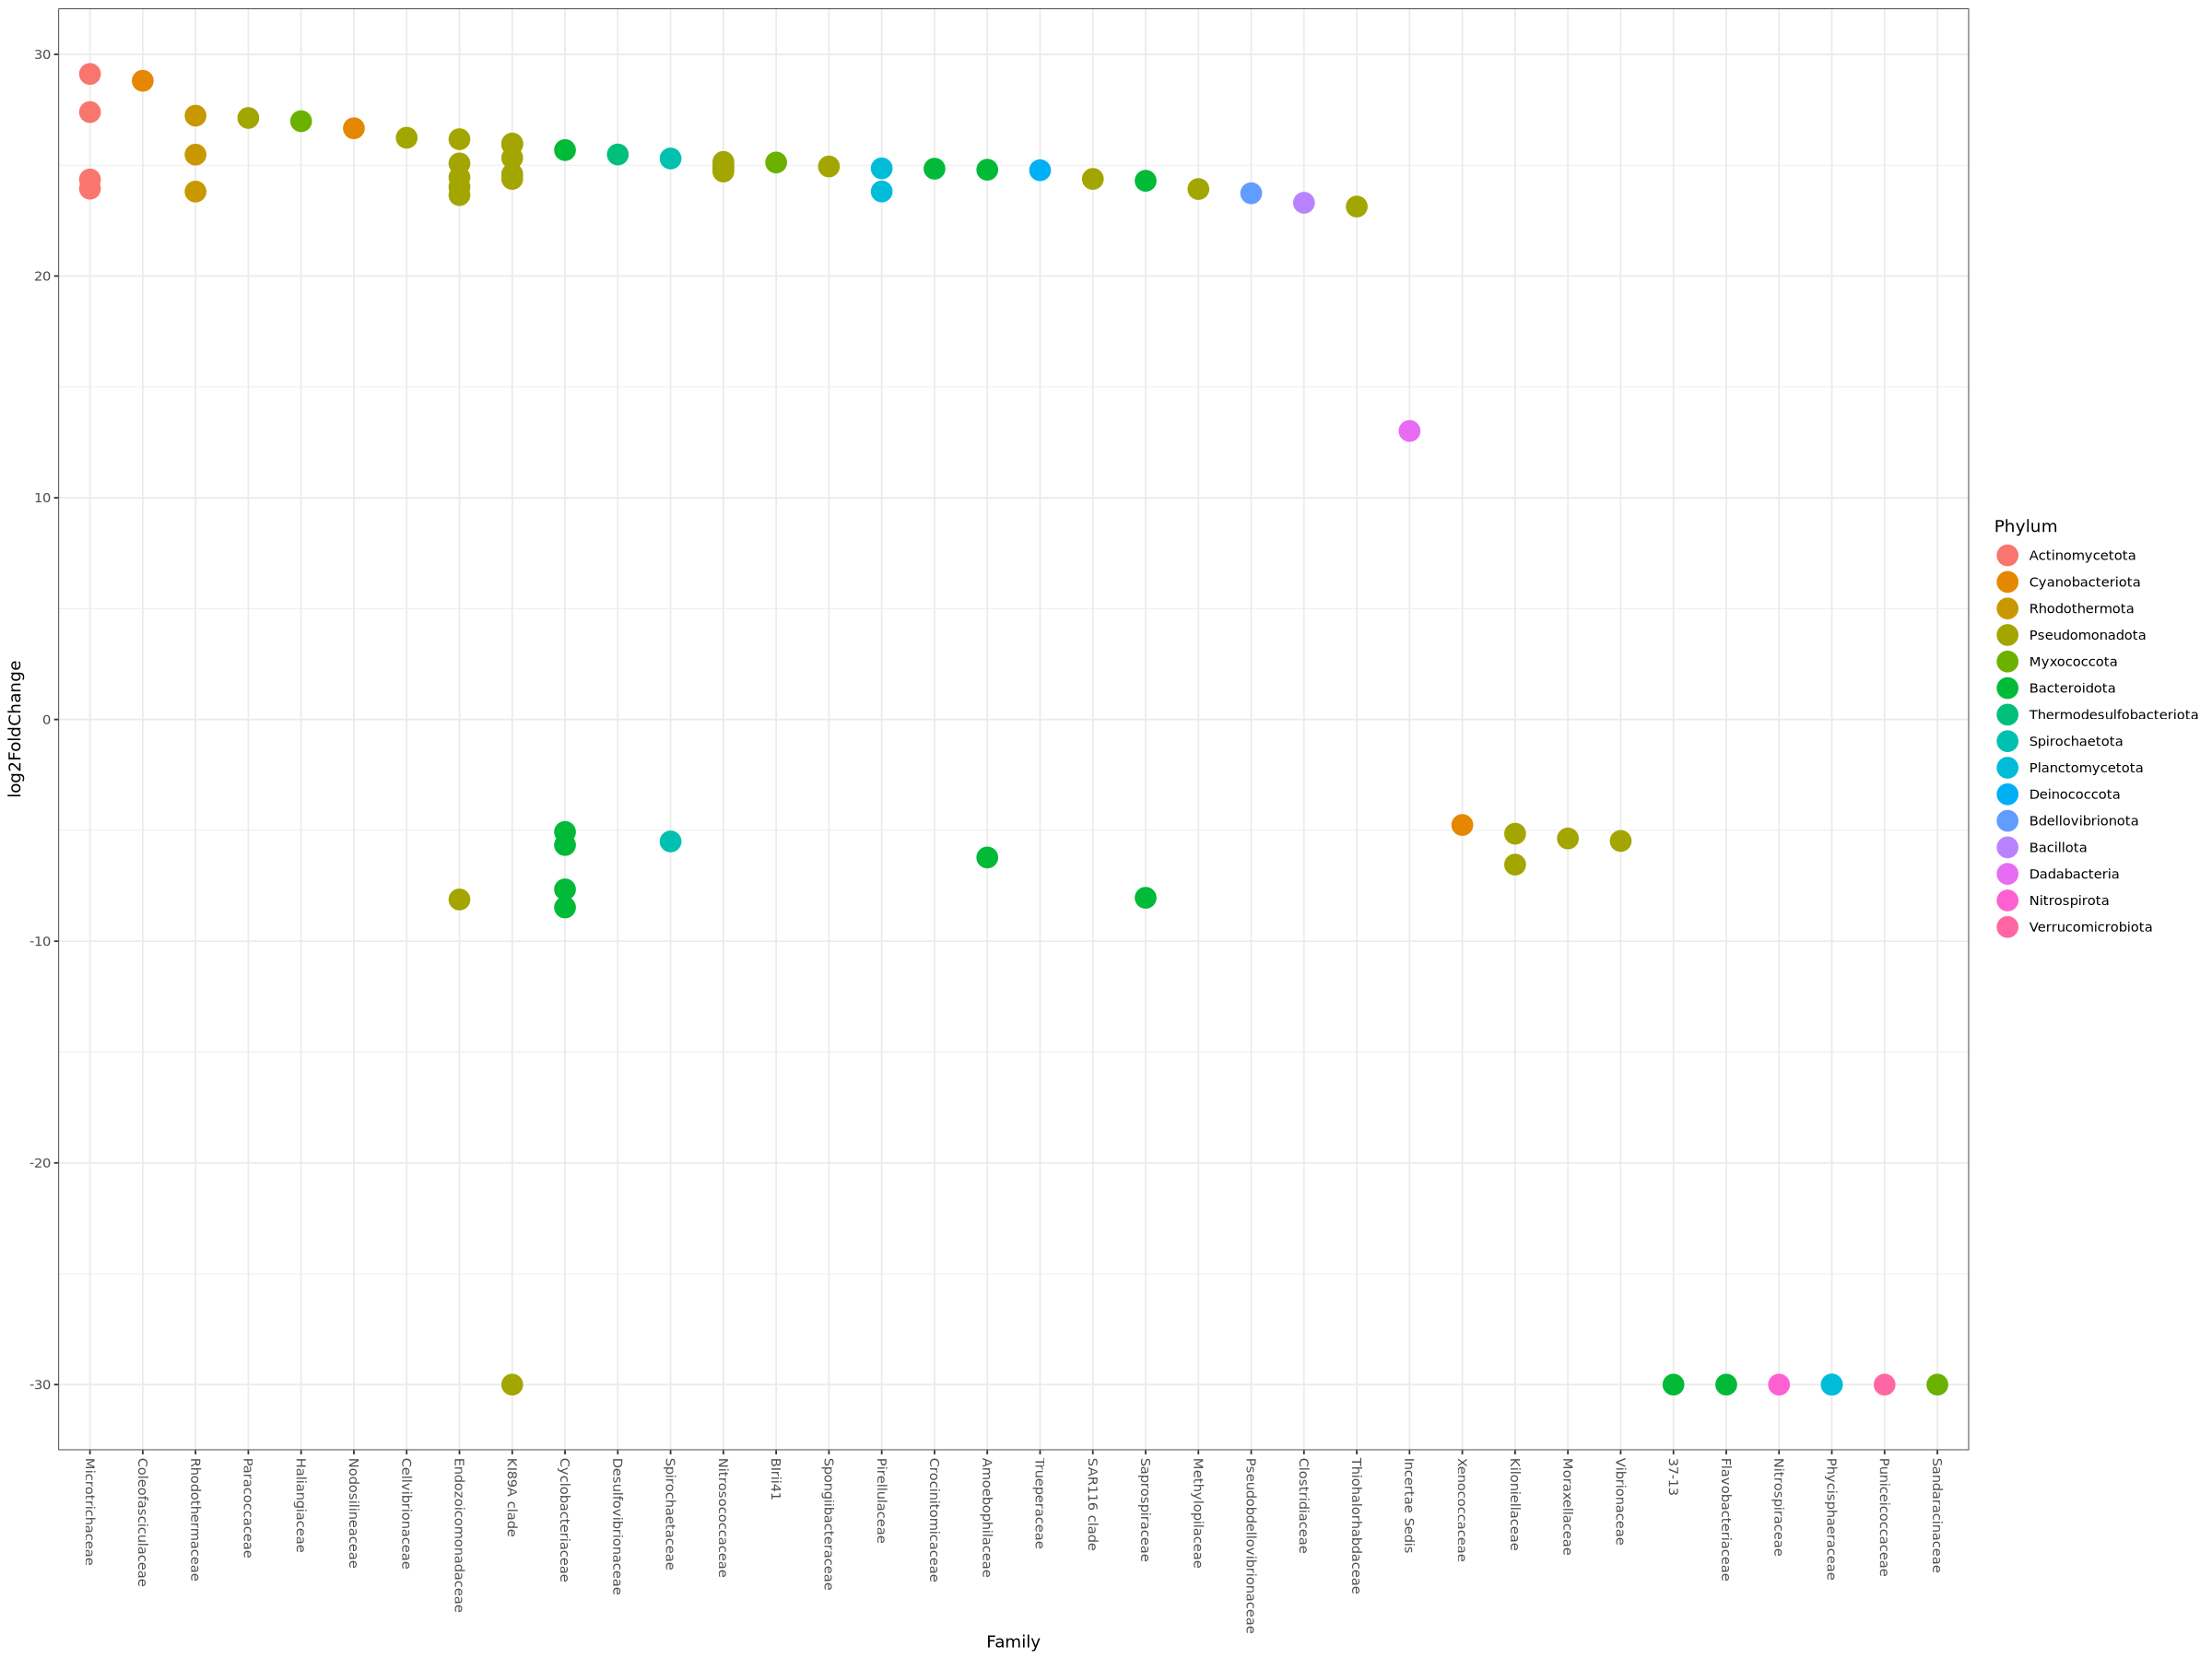

In [110]:
theme_set(theme_bw())
scale_fill_discrete <- function(palname = "Set1", ...) {
    scale_fill_brewer(palette = palname, ...)
}
# Phylum order
x = tapply(sigtab$log2FoldChange, sigtab$Phylum, function(x) max(x))
x = sort(x, TRUE)
sigtab$Phylum = factor(as.character(sigtab$Phylum), levels=names(x))
# Genus order
x = tapply(sigtab$log2FoldChange, sigtab$Family, function(x) max(x))
x = sort(x, TRUE)
sigtab$Family = factor(as.character(sigtab$Family), levels=names(x))
ggplot(sigtab, aes(x=Family, y=log2FoldChange, color=Phylum)) + geom_point(size=6) + 
  theme(axis.text.x = element_text(angle = -90, hjust = 0, vjust=0.5))

## okay what the hell does this mean